<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/3B_EWS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pymupdf transformers torch pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 28.1 MB/s eta 0:00:00


In [ ]:
import fitz
import pandas as pd
# Quarterly Earnings Presentation
# pdf_path = "/content/earnings_presentation_q4_fy26_v1.pdf"
# Valuation Report
# pdf_path = "/content/eop_reit_valuation_report_march_2026.pdf"
# Earnigns call report for DLF
pdf_path = "/content/Q4-Transcript-18-05-24.pdf"
doc = fitz.open(pdf_path)

pages = []

for page_num in range(len(doc)):
    text = doc.load_page(page_num).get_text()
    pages.append({
        "page": page_num + 1,
        "text": text
    })

df = pd.DataFrame(pages)

print(df.head())

   page                                               text
0     1   \n \nPage 1 of 19 \n \n \n“DLF Limited \n Q4 ...
1     2   \nDLF Limited \nMay 14, 2024 \n \n \nPage 2 o...
2     3   \nDLF Limited \nMay 14, 2024 \n \n \nPage 3 o...
3     4   \nDLF Limited \nMay 14, 2024 \n \n \nPage 4 o...
4     5   \nDLF Limited \nMay 14, 2024 \n \n \nPage 5 o...


In [ ]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
        model="ProsusAI/finbert"
        )

In [ ]:
results = []

for idx, row in df.iterrows():
    text = row["text"][:512]
    try:
        sentiment = classifier(text)[0]
        results.append({
            "page": row["page"],
            "label": sentiment["label"],
            "score": sentiment["score"]
        })
    except:
        results.append({
            "page": row["page"],
            "label": "ERROR",
            "score": 0
        })

sentiment_df = pd.DataFrame(results)
sentiment_df.head()

,page,label,score
0,1,neutral,0.939993
1,2,neutral,0.862969
2,3,neutral,0.943208
3,4,neutral,0.915923
4,5,neutral,0.915567


In [ ]:
sentiment_df

,page,label,score
0,1,neutral,0.939993
1,2,neutral,0.862969
2,3,neutral,0.943208
3,4,neutral,0.915923
4,5,neutral,0.915567
5,6,neutral,0.927712
6,7,neutral,0.859596
7,8,neutral,0.727811
8,9,neutral,0.892263
9,10,neutral,0.851063


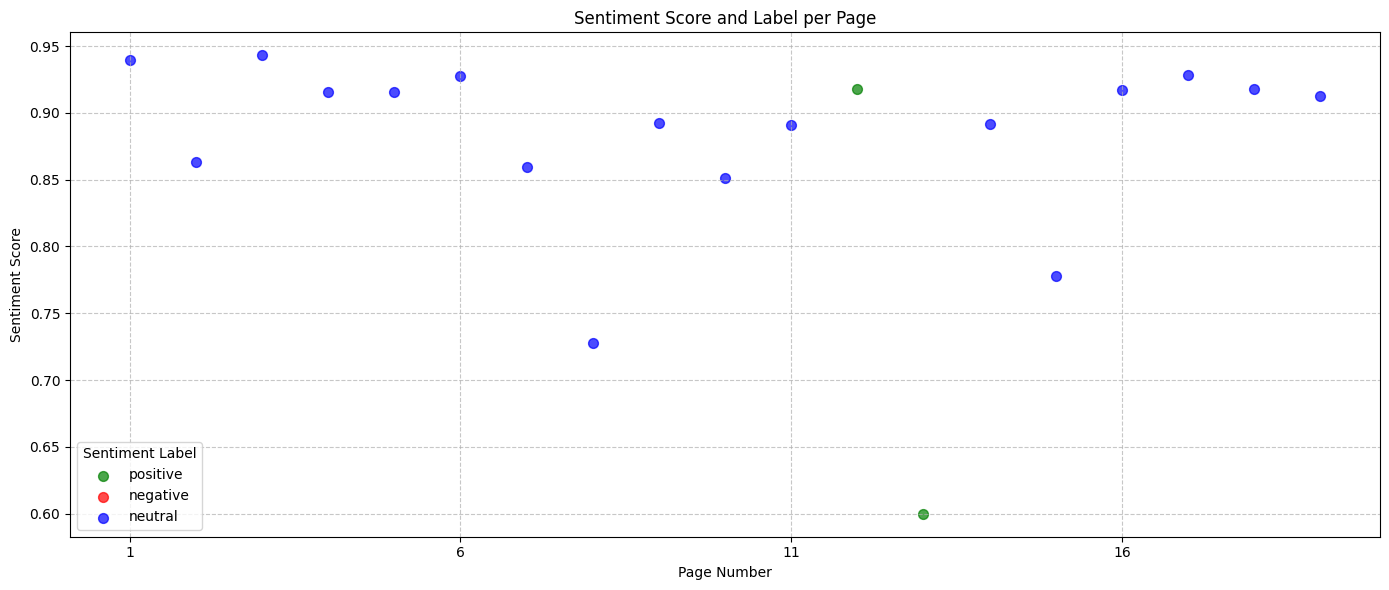

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a color map for sentiments
colors = {'positive': 'green', 'negative': 'red', 'neutral': 'blue'}

plt.figure(figsize=(14, 6))

# Plot scatter points for each sentiment label with different colors
for label, color in colors.items():
    subset = sentiment_df[sentiment_df['label'] == label]
    plt.scatter(subset['page'], subset['score'], color=color, label=label, s=50, alpha=0.7)

plt.xlabel("Page Number")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Score and Label per Page")
# Adjust x-axis ticks for better readability, showing page numbers every 5 pages
plt.xticks(np.arange(min(sentiment_df['page']), max(sentiment_df['page'])+1, 5))
plt.legend(title="Sentiment Label")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
risk_words = [
    "vacancy",
    "liquidity",
    "uncertainty",
    "risk",
    "slowdown",
    "headwinds",
    "debt",
    "macro",
    "volatility"
]

def count_risk_words(text):

    text = text.lower()

    count = 0

    found = []

    for word in risk_words:

        if word in text:
            count += 1
            found.append(word)

    return count, found

In [ ]:
risk_counts = []

for idx, row in df.iterrows():
    count, found = count_risk_words(row["text"])
    risk_counts.append({
        "page": row["page"],
        "risk_count": count,
        "keywords": found
    })

risk_df = pd.DataFrame(risk_counts)

risk_df.head()

In [ ]:
final_df = sentiment_df.merge(
    risk_df,
    on="page"
)

final_df.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    final_df["page"],
    final_df["risk_count"]
)

plt.xlabel("Page")
plt.ylabel("Governance Signal Density")
plt.title("CRE Governance Risk Signals")

plt.show()

In [ ]:
import re

valuation_keywords = [
    "valuation",
    "approach",
    "methodology",
    "discounted cash flow",
    "DCF",
    "asset-based",
    "market multiple",
    "income approach",
    "cost approach",
    "appraisal"
]

# Create a regex pattern to search for any of the keywords, case-insensitive
pattern = re.compile(r'|'.join(valuation_keywords), re.IGNORECASE)

# Filter the DataFrame to find pages containing any of the valuation keywords
valuation_pages = df[df['text'].apply(lambda x: bool(pattern.search(x)))]

display(valuation_pages)

In [ ]:
import fitz
import pandas as pd

# The annual_report_paths variable is available in the kernel state
# It contains paths to the annual report PDFs for different years.
annual_report_paths = {
    2020: "/content/eopr-new-annual-report-fy2020.pdf",
    2021: "/content/embassy_reit_ar_2021_web.pdf",
    2022: "/content/final_annual_report_2021_2022.pdf",
    2023: "/content/embassy_reit_-_annual_report_-_fy_2022-23.pdf",
    2024: "/content/embassy_reit_ar_2024_final.pdf",
    2025: "/content/annual_report_2025.pdf"
}

all_reports_data = []

print("Processing annual reports...")
for year, file_path in annual_report_paths.items():
    try:
        doc = fitz.open(file_path)
        for page_num in range(len(doc)):
            text = doc.load_page(page_num).get_text().strip()
            if text: # Only add non-empty text pages for duplicate checking
                all_reports_data.append({
                    'report_year': year,
                    'page_number': page_num + 1,
                    'text': text
                })
        print(f"Successfully processed {file_path} for year {year}.")
    except Exception as e:
        print(f"Error processing {file_path} for year {year}: {e}")

all_reports_df = pd.DataFrame(all_reports_data)

print(f"\nTotal unique pages (with non-empty text) extracted: {len(all_reports_df)}")

# --- Check for duplicates across annual reports ---
# Group by text and count the number of unique report_years for each text.
text_occurrences = all_reports_df.groupby('text').agg(
    unique_report_years=('report_year', 'nunique'),
    all_report_years=('report_year', lambda x: sorted(list(x.unique()))),
    total_occurrences=('text', 'size')
).reset_index()

cross_report_duplicates = text_occurrences[text_occurrences['unique_report_years'] > 1]

if not cross_report_duplicates.empty:
    print("\n--- DUPLICATE CONTENT FOUND ACROSS DIFFERENT ANNUAL REPORTS ---")
    print("The following text content appears in multiple annual reports (showing first 5 examples):")
    # Display a summary of the duplicates
    display(cross_report_duplicates.head())

    # Display details of the first few unique cross-report duplicated texts
    print("\n--- Details of some cross-report duplicated pages (first 3 unique texts) ---")
    for index, row in cross_report_duplicates.head(3).iterrows():
        print(f"\nDuplicate Text (first 100 chars): {row['text'][:100]}...")
        # Find all pages where this specific text appears
        pages_with_this_text = all_reports_df[all_reports_df['text'] == row['text']]
        display(pages_with_this_text[['report_year', 'page_number']])
else:
    print("\nNo duplicate text content found across different annual reports.")

# --- Check for duplicates within the same annual report ---
# This means the same text appears on multiple pages within the *same* annual report.
intra_report_duplicates_df = all_reports_df.groupby(['report_year', 'text']).size().reset_index(name='count')
intra_report_duplicates_df = intra_report_duplicates_df[intra_report_duplicates_df['count'] > 1]

# Filter out duplicates that are already identified as cross-report duplicates to focus on purely intra-report ones.
# A text is a pure intra-report duplicate if its text only appears within a single year, but multiple times in that year.
# First, identify texts that are ONLY intra-report duplicates (not cross-report)
texts_only_intra_report = intra_report_duplicates_df[
    ~intra_report_duplicates_df['text'].isin(cross_report_duplicates['text'])
]

if not texts_only_intra_report.empty:
    print("\n--- DUPLICATE CONTENT FOUND PURELY WITHIN THE SAME ANNUAL REPORTS ---")
    print("The following text content appears on multiple pages within a single annual report (showing first 5 examples):")
    display(texts_only_intra_report.head())

    # Optionally, display the actual pages for a few of these duplicates for inspection
    print("\n--- Details of some purely intra-report duplicated pages (first 3 unique texts) ---")
    for index, row in texts_only_intra_report.head(3).iterrows():
        print(f"\nDuplicate Text (first 100 chars) in Year {row['report_year']}: {row['text'][:100]}...")
        pages_with_this_text_in_year = all_reports_df[(all_reports_df['text'] == row['text']) & (all_reports_df['report_year'] == row['report_year'])]
        display(pages_with_this_text_in_year[['report_year', 'page_number']])
else:
    print("\nNo duplicate text content found purely within any single annual report (excluding those also found across reports).")

In [ ]:
import re

# Define keywords for each financial category
financial_keywords = {
    "Liquidity": ["liquidity", "cash flow", "working capital", "current assets", "current liabilities", "cash balance"],
    "Debt": ["debt", "borrowing", "loan", "leverage", "indebtedness", "bond", "mortgage", "financing costs"],
    "NOI": ["net operating income", "NOI", "operating income", "property income", "rental income net"],
    "Capitalization Rate": ["capitalization rate", "cap rate", "yield", "valuation yield"]
}

# Function to find keywords and their counts
def analyze_financial_terms(text, keywords_dict):
    found_terms = {category: [] for category in keywords_dict.keys()}
    for category, terms in keywords_dict.items():
        for term in terms:
            # Use regex to find all occurrences, case-insensitive
            matches = re.findall(r'\b' + re.escape(term) + r'\b', text, re.IGNORECASE)
            if matches:
                found_terms[category].extend(matches)
    return {category: len(terms_list) for category, terms_list in found_terms.items()}

# Apply the analysis function to each page of the annual reports
financial_analysis_results = []

for index, row in all_reports_df.iterrows():
    page_analysis = analyze_financial_terms(row['text'], financial_keywords)
    financial_analysis_results.append({
        'report_year': row['report_year'],
        'page_number': row['page_number'],
        **page_analysis
    })

# Create a DataFrame from the results
financial_trends_df = pd.DataFrame(financial_analysis_results)

# Display the head of the new DataFrame
print("Financial Term Occurrences per Page:")
display(financial_trends_df.head())


Financial Term Occurrences per Page:


,report_year,page_number,Liquidity,Debt,NOI,Capitalization Rate
0,2020,1,0,0,0,0
1,2020,2,0,1,2,0
2,2020,3,0,0,0,0
3,2020,5,0,0,0,0
4,2020,6,0,0,0,0


In [ ]:
# Aggregate the counts by year to see overall trends
yearly_trends = financial_trends_df.groupby('report_year').sum().reset_index()

print("\nYearly Trends of Financial Term Occurrences:")
display(yearly_trends)



Yearly Trends of Financial Term Occurrences:


,report_year,page_number,Liquidity,Debt,NOI,Capitalization Rate
0,2020,59577,103,245,72,22
1,2021,65355,131,306,81,20
2,2022,68963,136,356,67,7
3,2023,18915,140,394,91,9
4,2024,23871,174,411,81,21
5,2025,46056,193,485,224,72


The tables above show the raw counts of financial keywords found per page and then aggregated by year. We can use this to visualize trends over time.

In [ ]:
import plotly.express as px

# Create a figure with subplots for each financial term
fig = px.line(
    yearly_trends,
    x='report_year',
    y=['Liquidity', 'Debt', 'NOI', 'Capitalization Rate'],
    title='Trends of Financial Term Occurrences Over Years',
    labels={'report_year': 'Year', 'value': 'Number of Occurrences', 'variable': 'Financial Term'},
    markers=True # Add markers for each data point
)

# Update layout for better readability
fig.update_layout(
    hovermode='x unified',
    xaxis_title='Report Year',
    yaxis_title='Total Occurrences',
    legend_title='Financial Term',
    height=500 # Adjust height for better visualization
)

fig.show()

In [4]:
import requests
import os
import re # Added import for regular expressions

# --- User will need to update these URLs ---
# Example placeholder URLs for demonstration.
# You need to find the actual PDF links from www.dlf.in/investor and list them here.
pdf_urls = [
    "https://www.dlf.in/qu-result/Q4-and-FY24-Results-Presentation.pdf", # Q4 and FY24 Analyst Presentation
    "https://www.dlf.in/qu-result/CONSOL_Q4_2024.pdf" # Q4 and Consolidated Annual results
]

download_dir = "./downloaded_pdfs"
os.makedirs(download_dir, exist_ok=True)

for url in pdf_urls:
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

        # Extract filename from URL or assign a default name
        filename = os.path.join(download_dir, os.path.basename(url))
        if not filename.endswith('.pdf'):
            # If URL doesn't end with .pdf, try to get from content-disposition header
            if 'content-disposition' in response.headers:
                d = response.headers['content-disposition']
                # Corrected the regex pattern to be a single, valid string
                fname_match = re.findall(r'filename="?([^" ]+)"?', d)
                if fname_match:
                    filename = os.path.join(download_dir, fname_match[0])
            else:
                # Fallback if no .pdf in URL and no content-disposition
                filename = os.path.join(download_dir, "downloaded_file_" + str(pdf_urls.index(url)) + ".pdf")

        with open(filename, 'wb') as pdf_file:
            for chunk in response.iter_content(chunk_size=8192):
                pdf_file.write(chunk)
        print(f"Successfully downloaded: {filename}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {url}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred for {url}: {e}")

print(f"All PDFs downloaded to: {download_dir}")

Successfully downloaded: ./downloaded_pdfs/Q4-and-FY24-Results-Presentation.pdf
Successfully downloaded: ./downloaded_pdfs/CONSOL_Q4_2024.pdf
All PDFs downloaded to: ./downloaded_pdfs


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Analyzing: Q4-and-FY24-Results-Presentation.pdf
Analyzing: CONSOL_Q4_2024.pdf

Combined Analysis Results (first 5 rows):


,page,label,score,risk_count,keywords,document
0,1,neutral,0.937689,0,[],Q4-and-FY24-Results-Presentation.pdf
1,2,neutral,0.944120,0,[],Q4-and-FY24-Results-Presentation.pdf
2,3,positive,0.656182,0,[],Q4-and-FY24-Results-Presentation.pdf
3,4,positive,0.954617,0,[],Q4-and-FY24-Results-Presentation.pdf
4,5,positive,0.908918,0,[],Q4-and-FY24-Results-Presentation.pdf


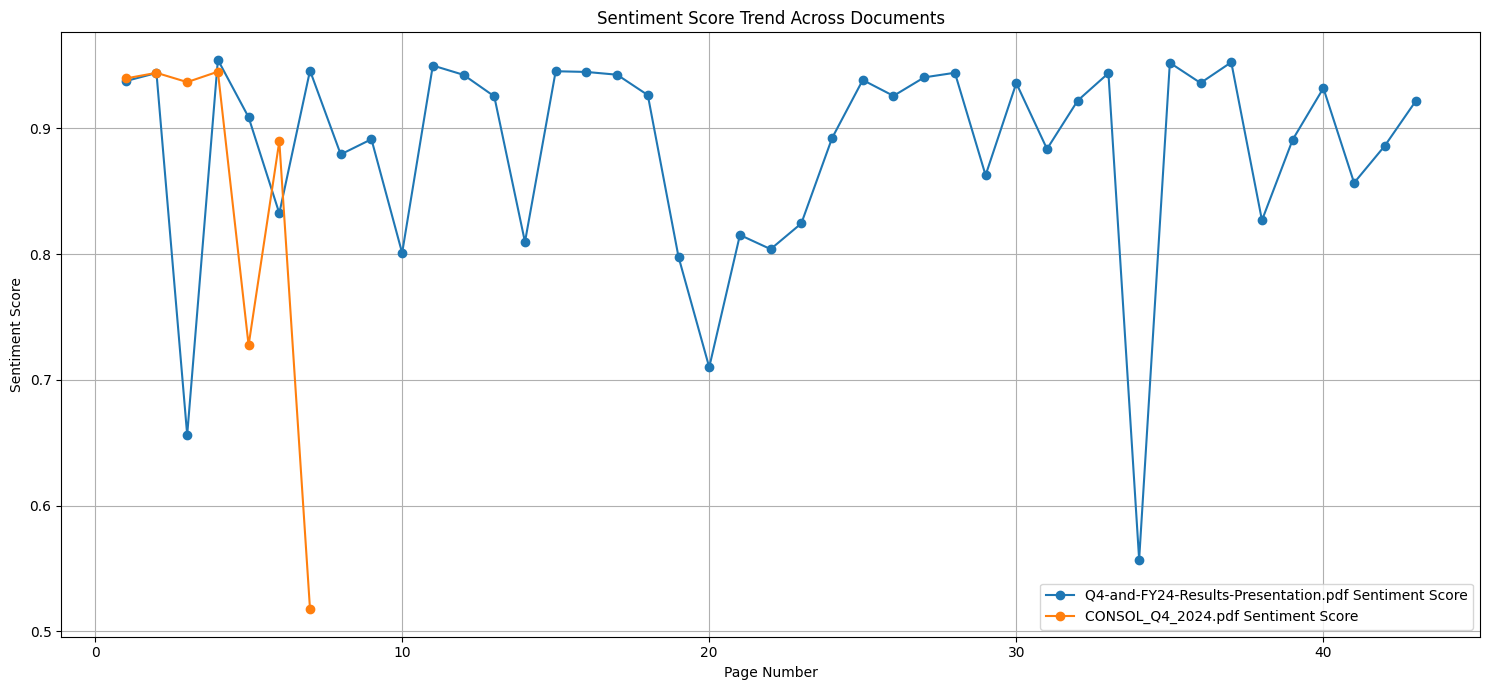

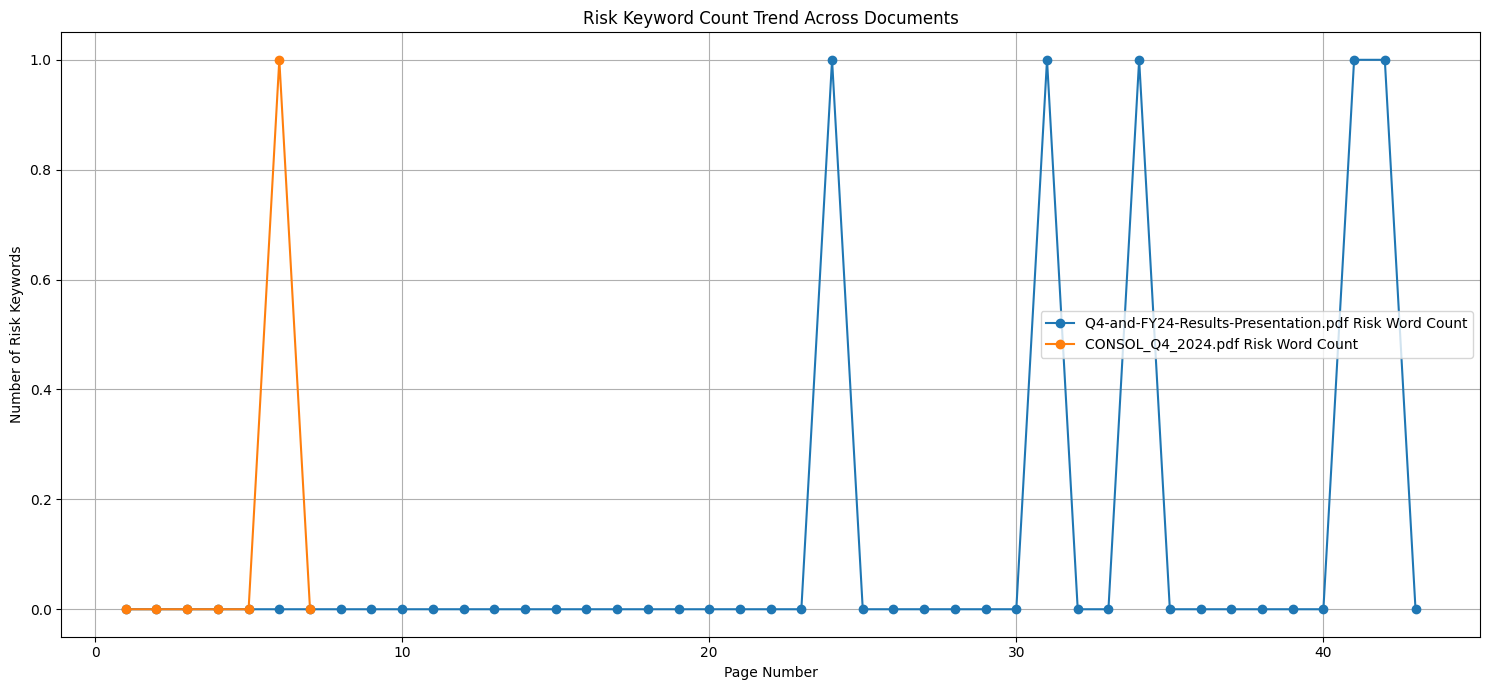

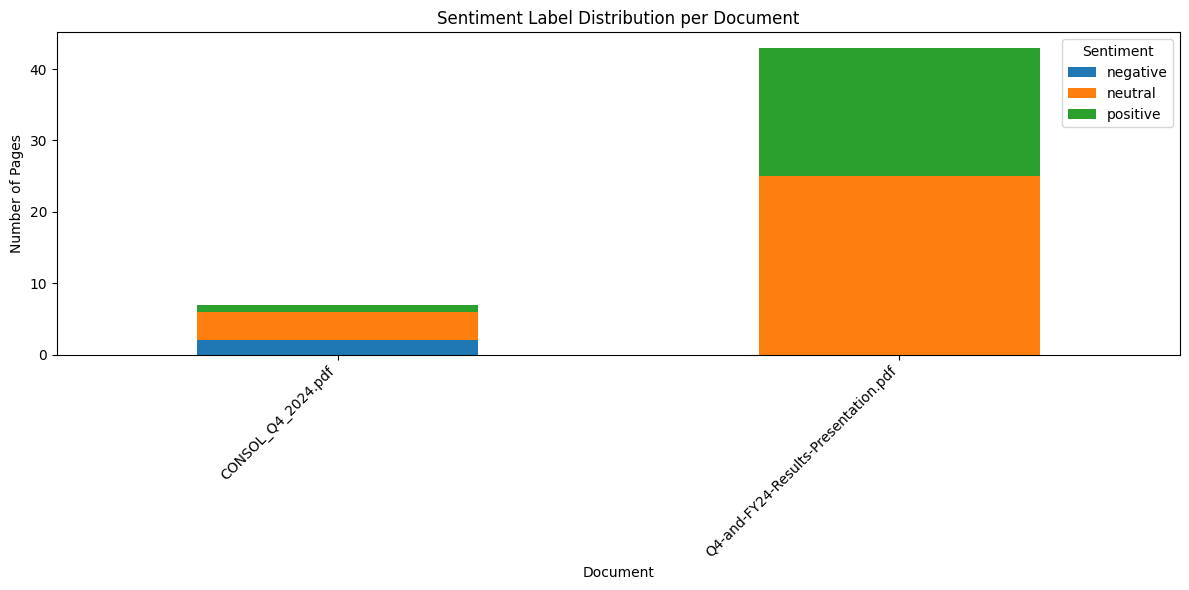

In [7]:
import fitz
import pandas as pd
import matplotlib.pyplot as plt
import os
from transformers import pipeline # Added import for pipeline

# --- Definitions for risk word counting ---
risk_words = [
    "vacancy",
    "liquidity",
    "uncertainty",
    "risk",
    "slowdown",
    "headwinds",
    "debt",
    "macro",
    "volatility"
]

def count_risk_words(text):
    text = text.lower()
    count = 0
    found = []
    for word in risk_words:
        if word in text:
            count += 1
            found.append(word)
    return count, found
# --- End of definitions for risk word counting ---

# --- Sentiment Classifier Definition ---
# The classifier is now defined in this cell to ensure it's always available.
classifier = pipeline(
    "sentiment-analysis",
        model="ProsusAI/finbert"
        )
# --- End of Sentiment Classifier Definition ---

# Define the paths to the newly downloaded PDF files
new_pdf_paths = [
    os.path.join(download_dir, "Q4-and-FY24-Results-Presentation.pdf"),
    os.path.join(download_dir, "CONSOL_Q4_2024.pdf")
]

def process_pdf_for_analysis(pdf_path):
    doc = fitz.open(pdf_path)
    pages_data = []

    for page_num in range(len(doc)):
        text = doc.load_page(page_num).get_text()
        pages_data.append({
            "page": page_num + 1,
            "text": text
        })

    df_pdf = pd.DataFrame(pages_data)

    # Apply sentiment analysis
    sentiment_results = []
    for idx, row in df_pdf.iterrows():
        text = row["text"][:512] # Limit text length for sentiment model
        if not text.strip(): # Skip empty text to avoid classifier errors
            sentiment_results.append({
                "page": row["page"],
                "label": "N/A", # Label for empty pages
                "score": 0
            })
            continue
        try:
            sentiment = classifier(text)[0]
            sentiment_results.append({
                "page": row["page"],
                "label": sentiment["label"],
                "score": sentiment["score"]
            })
        except Exception as e:
            print(f"Error classifying sentiment for page {row['page']} of {os.path.basename(pdf_path)}: {e}")
            sentiment_results.append({
                "page": row["page"],
                "label": "ERROR",
                "score": 0
            })
    sentiment_df_pdf = pd.DataFrame(sentiment_results)

    # Apply risk word counting
    risk_counts_pdf = []
    for idx, row in df_pdf.iterrows():
        count, found = count_risk_words(row["text"])
        risk_counts_pdf.append({
            "page": row["page"],
            "risk_count": count,
            "keywords": found
        })
    risk_df_pdf = pd.DataFrame(risk_counts_pdf)

    # Merge sentiment and risk data
    combined_df = sentiment_df_pdf.merge(risk_df_pdf, on="page")
    combined_df['document'] = os.path.basename(pdf_path) # Add document name
    return combined_df

all_documents_analysis = []

for pdf_file in new_pdf_paths:
    print(f"Analyzing: {os.path.basename(pdf_file)}")
    analysis_df = process_pdf_for_analysis(pdf_file)
    all_documents_analysis.append(analysis_df)

# Concatenate all analysis results into a single DataFrame
final_comparison_df = pd.concat(all_documents_analysis, ignore_index=True)

print("\nCombined Analysis Results (first 5 rows):")
display(final_comparison_df.head())

# --- Plotting Trends Across Documents ---

# 1. Sentiment Score Trend
plt.figure(figsize=(15, 7))
for doc_name in final_comparison_df['document'].unique():
    subset = final_comparison_df[final_comparison_df['document'] == doc_name]
    # Filter out 'ERROR' and 'N/A' labels for plotting sentiment scores
    subset_to_plot = subset[~subset['label'].isin(['ERROR', 'N/A'])]
    if not subset_to_plot.empty:
        plt.plot(subset_to_plot['page'], subset_to_plot['score'], marker='o', label=f'{doc_name} Sentiment Score')
plt.xlabel('Page Number')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Score Trend Across Documents')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Risk Word Count Trend
plt.figure(figsize=(15, 7))
for doc_name in final_comparison_df['document'].unique():
    subset = final_comparison_df[final_comparison_df['document'] == doc_name]
    plt.plot(subset['page'], subset['risk_count'], marker='o', label=f'{doc_name} Risk Word Count')
plt.xlabel('Page Number')
plt.ylabel('Number of Risk Keywords')
plt.title('Risk Keyword Count Trend Across Documents')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Aggregated Sentiment Label Distribution
plt.figure(figsize=(12, 6))
# Filter out 'ERROR' and 'N/A' labels from the distribution if desired, or keep them to show problems
sentiment_distribution = final_comparison_df.groupby(['document', 'label']).size().unstack(fill_value=0)
sentiment_distribution.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Sentiment Label Distribution per Document')
plt.xlabel('Document')
plt.ylabel('Number of Pages')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


DataFrame with text column (first 5 rows):


,page,label,score,risk_count,keywords,document,text
0,1,neutral,0.937689,0,[],Q4-and-FY24-Results-Presentation.pdf,DLF Limited\n FY24 Results Presentation\nPriva...
1,2,neutral,0.944120,0,[],Q4-and-FY24-Results-Presentation.pdf,AGENDA\nOverview\n01\nDLF Limited\nBusiness Up...
2,3,positive,0.656182,0,[],Q4-and-FY24-Results-Presentation.pdf,DLF Group – Business Overview\nResidential\nOf...
3,4,positive,0.954617,0,[],Q4-and-FY24-Results-Presentation.pdf,Outlook\nIndustry\nIndia’s economy continues t...
4,5,positive,0.908918,0,[],Q4-and-FY24-Results-Presentation.pdf,DLF Group– Key Business Priorities\nValue Crea...



--- Interpretable Governance-Oriented Signal Explanation Table ---


,Page,Signal Type,Theme,Extract Summary,Document
0,3,Liquidity,Liquidity Concern,": +91-124-4334200, Fax:+91-124-4769250 Stateme...",CONSOL_Q4_2024.pdf
1,6,Financing,Financing Stress,Notes to the Consolidated Financial Results ...,CONSOL_Q4_2024.pdf
2,5,Sentiment Drop,General,Notes to the Consolidated Financial Results ...,CONSOL_Q4_2024.pdf
3,2,Liquidity,Liquidity Concern,": +91-124-4334200, Fax:+91-124-4769250 Stateme...",CONSOL_Q4_2024.pdf
4,3,Financing,Financing Stress,": +91-124-4334200, Fax:+91-124-4769250 Stateme...",CONSOL_Q4_2024.pdf
5,7,Sentiment Drop,General,Notes to the Consolidated Financial Results ...,CONSOL_Q4_2024.pdf
6,6,Risk Spike,General Risk,Notes to the Consolidated Financial Results ...,CONSOL_Q4_2024.pdf
7,24,Financing,Financing Stress,Net Cash Position – Q4FY24 Net Cash position...,Q4-and-FY24-Results-Presentation.pdf
8,25,Liquidity,Liquidity Concern,Surplus Cash Potential Healthy cashflows led ...,Q4-and-FY24-Results-Presentation.pdf
9,34,Sentiment Drop,General,Result Highlights – FY24 Rental income grew b...,Q4-and-FY24-Results-Presentation.pdf


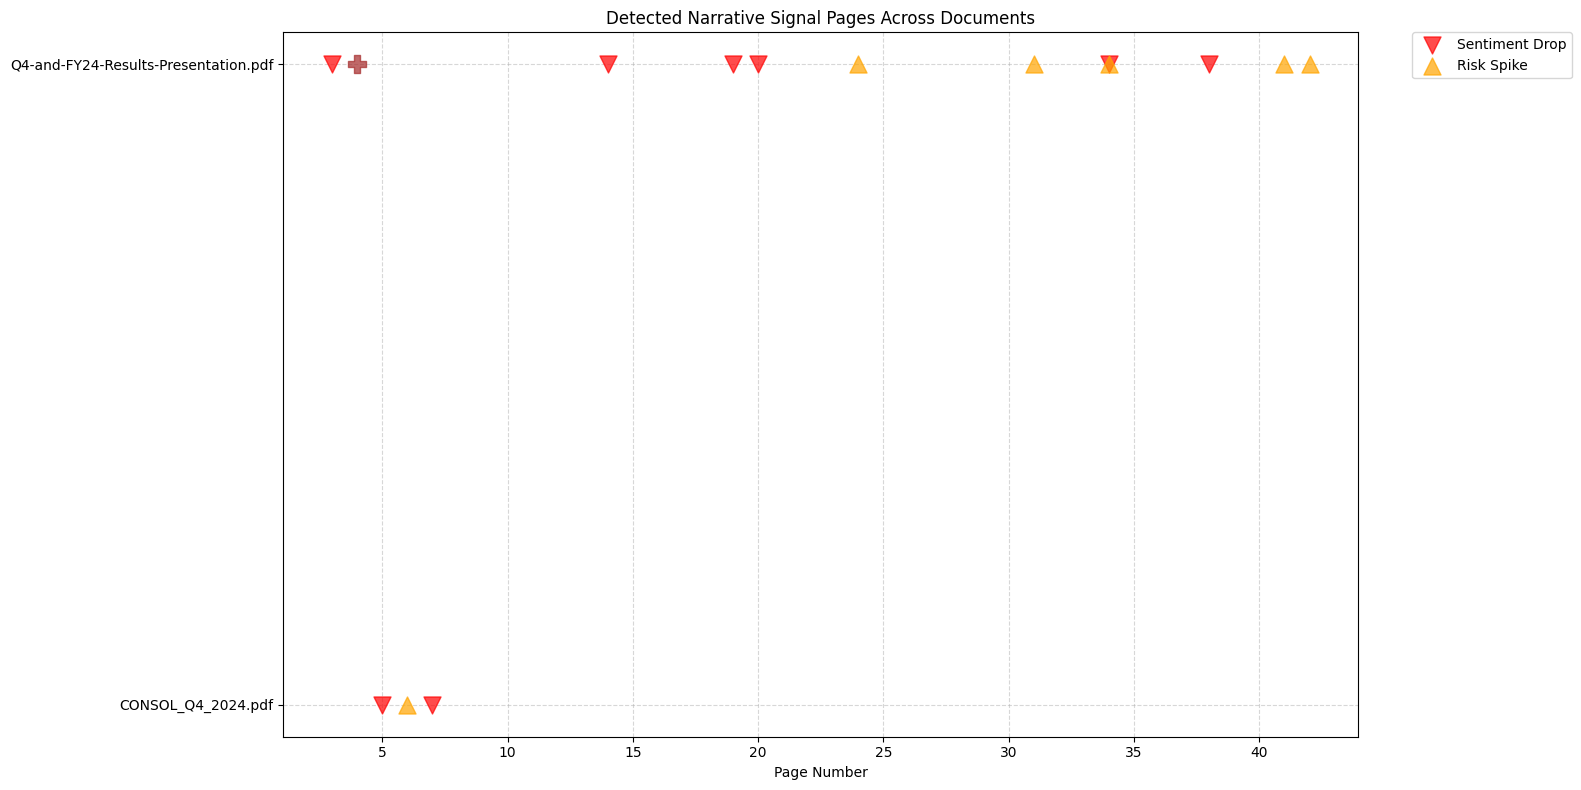

In [10]:
import numpy as np
import re
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt

# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab') # Punkt_tab is also needed for sent_tokenize
except LookupError:
    nltk.download('punkt_tab')

# --- 1. Re-construct final_comparison_df with 'text' column ---
# The `process_pdf_for_analysis` function from cell YIfC8oLyihTP did not merge 'text'.
# Re-doing the data loading to ensure 'text' is present in the final DataFrame.

def get_text_for_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    pages_text = []
    for page_num in range(len(doc)):
        text = doc.load_page(page_num).get_text()
        pages_text.append({
            "page": page_num + 1,
            "text": text,
            "document": os.path.basename(pdf_path)
        })
    return pd.DataFrame(pages_text)

# Get all texts from the original PDF files
all_raw_texts_df = pd.concat([get_text_for_pdf(path) for path in new_pdf_paths], ignore_index=True)

# Merge the existing final_comparison_df (which has sentiment/risk data) with raw texts
# This ensures the 'text' column is available for summary extraction.
final_comparison_df_with_text = pd.merge(
    final_comparison_df,
    all_raw_texts_df,
    on=['page', 'document'],
    how='left'
)

# Handle potential missing text (should not happen if merge is correct)
final_comparison_df_with_text['text'] = final_comparison_df_with_text['text'].fillna('')

print("DataFrame with text column (first 5 rows):")
display(final_comparison_df_with_text.head())

# --- 2. Define Thematic Keywords and Categories ---
# These will be used to classify signal themes and extract summaries.

thematic_keywords = {
    "Liquidity Concern": ["liquidity", "cash flow", "working capital", "funding", "short-term debt", "cash position", "receivables", "payables"],
    "Financing Stress": ["debt", "borrowing", "loan", "repayment", "interest rate", "covenants", "refinancing", "default", "leverage"],
    "Guidance Caution": ["guidance", "outlook", "forecast", "projection", "expectations", "uncertainty", "cautious", "challenging", "conservative", "headwinds"],
    "Pricing Sustainability Concern": ["pricing", "rent growth", "yields", "valuation", "market rates", "demand", "supply", "vacancy", "inflation"],
    "Affordability Stress": ["affordability", "disposable income", "consumer spending", "interest rates", "housing burden", "wage growth", "cost of living"],
    "General Risk": risk_words # Using the previously defined risk_words for general risk
}

# --- 3. Define Thresholds for Signal Detection ---

# Sentiment Drop thresholds:
# Sentiment score below document average by this many standard deviations
SENTIMENT_BELOW_AVG_STD_FACTOR = 1.0 # Adjusted to 1.0 from 1.5 for potentially more signals
# Absolute drop in sentiment score from previous page
SHARP_SENTIMENT_DROP_THRESHOLD = 0.10 # e.g., a drop of 0.10 (10%) in score

# Risk Spike thresholds:
# Risk keyword count above this percentile for the document
RISK_COUNT_PERCENTILE_THRESHOLD = 90 # Top 10% of pages by risk count
# Risk keyword count above document average by this many standard deviations
RISK_COUNT_ABOVE_AVG_STD_FACTOR = 1.0 # Adjusted to 1.0 from 1.5

# Thematic Concentration thresholds:
# Minimum number of unique keywords from a theme required on a page to trigger a signal
THEMATIC_KEYWORD_MIN_COUNT = 2 # At least 2 unique keywords from a specific theme

# --- 4. Helper Function for Summary Extraction ---
def extract_summary(page_text, triggering_keywords, signal_type, sentiment_label=None, sentiment_score=None):
    sentences = sent_tokenize(page_text)
    best_sentences = []

    # Prioritize sentences containing the triggering keywords
    keyword_sentences = []
    for keyword in triggering_keywords:
        for sentence in sentences:
            if re.search(r'\b' + re.escape(keyword) + r'\b', sentence, re.IGNORECASE):
                keyword_sentences.append(sentence)

    if keyword_sentences:
        # Simple approach: take the first sentence that contains a keyword, or top 2
        unique_keyword_sentences = list(dict.fromkeys(keyword_sentences)) # Remove duplicates while preserving order
        best_sentences = unique_keyword_sentences[:2]

    # Fallback if no keyword sentences, or for sentiment drops specifically
    if not best_sentences and (signal_type == "Sentiment Drop" or sentiment_label == "negative"):
        # Try to find sentences that might explain negative sentiment
        negative_sentiment_terms = ["decline", "fall", "decrease", "loss", "worsen", "challenge", "difficult", "weak", "lower"]
        for term in negative_sentiment_terms:
            for sentence in sentences:
                if re.search(r'\b' + re.escape(term) + r'\b', sentence, re.IGNORECASE):
                    best_sentences.append(sentence)
                    if len(best_sentences) >= 2: break
            if len(best_sentences) >= 2: break
        best_sentences = list(dict.fromkeys(best_sentences))[:2]

    if not best_sentences:
        # If still no sentences, just take the first two sentences of the page
        best_sentences = sentences[:2]

    return " ".join(best_sentences).replace('\n', ' ').strip()[:200] + '...' # Truncate and clean

# --- 5. Signal Detection Logic ---

signals_detected = []

# Iterate through each document to calculate document-specific statistics
for doc_name in final_comparison_df_with_text['document'].unique():
    doc_df = final_comparison_df_with_text[final_comparison_df_with_text['document'] == doc_name].copy()

    # Filter out 'ERROR' and 'N/A' sentiment scores for calculations
    valid_sentiment_scores = doc_df[~doc_df['label'].isin(['ERROR', 'N/A'])]['score']
    doc_avg_sentiment = valid_sentiment_scores.mean() if not valid_sentiment_scores.empty else 0
    doc_std_sentiment = valid_sentiment_scores.std() if not valid_sentiment_scores.empty else 0

    doc_avg_risk_count = doc_df['risk_count'].mean()
    doc_std_risk_count = doc_df['risk_count'].std()
    risk_90th_percentile = doc_df['risk_count'].quantile(RISK_COUNT_PERCENTILE_THRESHOLD / 100) if not doc_df.empty else 0

    # Add shifted sentiment score for drop detection
    doc_df['prev_score'] = doc_df['score'].shift(1)

    for idx, row in doc_df.iterrows():
        page = row['page']
        text = row['text']
        sentiment_score = row['score']
        sentiment_label = row['label']
        risk_count = row['risk_count']
        prev_score = row['prev_score']

        # Initialize signal findings for the page
        page_signals = []

        # --- Signal: Sentiment Drop ---
        # Trigger 1: Significantly below document average
        if sentiment_label != 'ERROR' and sentiment_label != 'N/A' and \
           sentiment_score < (doc_avg_sentiment - SENTIMENT_BELOW_AVG_STD_FACTOR * doc_std_sentiment):

            triggering_keywords = [] # For sentiment, keywords are less direct for summary
            summary = extract_summary(text, triggering_keywords, "Sentiment Drop", sentiment_label=sentiment_label, sentiment_score=sentiment_score)
            page_signals.append({
                'Page': page,
                'Signal Type': 'Sentiment Drop',
                'Theme': 'General',
                'Extract Summary': summary,
                'Document': doc_name,
                'Signal_Strength': (doc_avg_sentiment - sentiment_score) / doc_std_sentiment if doc_std_sentiment else 0 # How many std devs below avg
            })
        # Trigger 2: Sharp drop from previous page
        elif sentiment_label != 'ERROR' and sentiment_label != 'N/A' and prev_score is not np.nan and \
             (prev_score - sentiment_score) > SHARP_SENTIMENT_DROP_THRESHOLD:

            triggering_keywords = []
            summary = extract_summary(text, triggering_keywords, "Sentiment Drop", sentiment_label=sentiment_label, sentiment_score=sentiment_score)
            page_signals.append({
                'Page': page,
                'Signal Type': 'Sentiment Drop',
                'Theme': 'General',
                'Extract Summary': summary,
                'Document': doc_name,
                'Signal_Strength': (prev_score - sentiment_score) / SHARP_SENTIMENT_DROP_THRESHOLD # Magnitude of drop
            })

        # --- Signal: Risk Spike ---
        # Trigger 1: Above 90th percentile for risk count
        if risk_count > risk_90th_percentile and risk_count > 0: # Ensure not zero risk_count

            triggering_keywords_found = [word for word in risk_words if re.search(r'\b' + re.escape(word) + r'\b', text, re.IGNORECASE)]
            summary = extract_summary(text, triggering_keywords_found, "Risk Spike")
            page_signals.append({
                'Page': page,
                'Signal Type': 'Risk Spike',
                'Theme': 'General Risk',
                'Extract Summary': summary,
                'Document': doc_name,
                'Signal_Strength': risk_count - risk_90th_percentile # How much above percentile
            })
        # Trigger 2: Significantly above document average risk count
        elif risk_count > (doc_avg_risk_count + RISK_COUNT_ABOVE_AVG_STD_FACTOR * doc_std_risk_count) and risk_count > 0:

            triggering_keywords_found = [word for word in risk_words if re.search(r'\b' + re.escape(word) + r'\b', text, re.IGNORECASE)]
            summary = extract_summary(text, triggering_keywords_found, "Risk Spike")
            page_signals.append({
                'Page': page,
                'Signal Type': 'Risk Spike',
                'Theme': 'General Risk',
                'Extract Summary': summary,
                'Document': doc_name,
                'Signal_Strength': (risk_count - doc_avg_risk_count) / doc_std_risk_count if doc_std_risk_count else 0 # How many std devs above avg
            })


        # --- Signal: Thematic Concentration / Risk Cluster ---
        # Check for specific thematic concerns
        for theme, keywords in thematic_keywords.items():
            if theme == "General Risk": continue # Handled by Risk Spike, or for a cluster

            found_theme_keywords = []
            for keyword in keywords:
                if re.search(r'\b' + re.escape(keyword) + r'\b', text, re.IGNORECASE):
                    found_theme_keywords.append(keyword)

            # If enough unique keywords from a theme are found
            if len(set(found_theme_keywords)) >= THEMATIC_KEYWORD_MIN_COUNT:
                # Avoid duplicating if already a Risk Spike with the same keywords, or prioritize specific theme
                is_duplicate_signal = False
                for existing_signal in page_signals:
                    if existing_signal['Signal Type'] == 'Risk Spike' and existing_signal['Theme'] == theme:
                        is_duplicate_signal = True
                        break

                if not is_duplicate_signal:
                    signal_type_name = theme.replace(' ', '') # Remove spaces for cleaner signal name
                    if signal_type_name.endswith('Concern'):
                        signal_type_name = signal_type_name.replace('Concern', '')
                    elif signal_type_name.endswith('Stress'):
                        signal_type_name = signal_type_name.replace('Stress', '')
                    # Special handling for 'Pricing Sustainability Concern' to match desired output
                    if theme == 'Pricing Sustainability Concern':
                        signal_type_name = 'Pricing Sustainability Concern'

                    summary = extract_summary(text, found_theme_keywords, theme)
                    page_signals.append({
                        'Page': page,
                        'Signal Type': signal_type_name, # Use cleaned name for Signal Type
                        'Theme': theme,
                        'Extract Summary': summary,
                        'Document': doc_name,
                        'Signal_Strength': len(set(found_theme_keywords)) # Number of unique thematic keywords
                    })

        signals_detected.extend(page_signals)

# --- 6. Create Final Explanations DataFrame ---
explanation_df = pd.DataFrame(signals_detected)

# Sort by signal strength (descending), then by page for consistent ordering
explanation_df = explanation_df.sort_values(by=['Document', 'Signal_Strength'], ascending=[True, False]).reset_index(drop=True)

# Clean up and select final columns
final_explanation_table = explanation_df[['Page', 'Signal Type', 'Theme', 'Extract Summary', 'Document']]

print("\n--- Interpretable Governance-Oriented Signal Explanation Table ---")
display(final_explanation_table)

# --- 7. Optional Visualization ---
plt.figure(figsize=(16, 8))

# Mapping for signal types to markers and colors
signal_styles = {
    'Sentiment Drop': {'marker': 'v', 'color': 'red', 'label': 'Sentiment Drop'},
    'Risk Spike': {'marker': '^', 'color': 'orange', 'label': 'Risk Spike'},
    'Liquidity Concern': {'marker': 's', 'color': 'blue', 'label': 'Liquidity Concern'},
    'Financing Stress': {'marker': 'D', 'color': 'purple', 'label': 'Financing Stress'},
    'Guidance Caution': {'marker': 'o', 'color': 'green', 'label': 'Guidance Caution'},
    'Pricing Sustainability Concern': {'marker': 'P', 'color': 'brown', 'label': 'Pricing Sustainability Concern'}, # Corrected name
    'Affordability Stress': {'marker': 'X', 'color': 'cyan', 'label': 'Affordability Stress'},
    'Risk Cluster': {'marker': '*', 'color': 'darkred', 'label': 'Risk Cluster'}
}

# Get unique documents and assign a numerical index for plotting on the y-axis
unique_documents = final_explanation_table['Document'].unique()
doc_y_map = {doc: i for i, doc in enumerate(unique_documents)}

# Plotting signals for each document
for i, doc_name in enumerate(unique_documents):
    doc_signals = final_explanation_table[final_explanation_table['Document'] == doc_name]
    y_base = doc_y_map[doc_name] # Base y-level for the current document

    for signal_type, style in signal_styles.items():
        subset = doc_signals[doc_signals['Signal Type'] == signal_type]
        if not subset.empty:
            plt.scatter(
                subset['Page'],
                np.full(len(subset), y_base), # All signals for this doc at the same y-level
                marker=style['marker'],
                color=style['color'],
                s=150,
                label=f'{style['label']}' if i == 0 else "", # Label only once for legend
                alpha=0.7,
                zorder=2 # Ensure markers are on top
            )

plt.yticks(list(doc_y_map.values()), list(doc_y_map.keys()), rotation=0)
plt.xlabel('Page Number')
plt.title('Detected Narrative Signal Pages Across Documents')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package wordnet to /root/nltk_data...



--- Redesigned Explainable Narrative Signal Framework ---


,Document,Page,Signal Type,Theme,Severity,Confidence,Extract Summary
0,CONSOL_Q4_2024.pdf,2-3,Liquidity & Cashflow Risk Cluster (2-3),Liquidity & Cashflow Risk,Moderate,Moderate,"DLF Limited Regd. Office: Shopping Mall, 3rd F..."
1,CONSOL_Q4_2024.pdf,5-7,General Sentiment Cluster (5-7),General Sentiment,Low,Moderate,Notes to the Consolidated Financial Results ...
2,Q4-and-FY24-Results-Presentation.pdf,3,Sentiment Discontinuity,General Sentiment,Low,Moderate,DLF Group – Business Overview Residential Offi...
3,Q4-and-FY24-Results-Presentation.pdf,5,Liquidity & Cashflow Risk,Liquidity & Cashflow Risk,Low,High,DLF Group– Key Business Priorities Value Creat...
4,Q4-and-FY24-Results-Presentation.pdf,14,Sentiment Discontinuity,General Sentiment,Low,Low,Project Execution Status : Area Under Developm...
5,Q4-and-FY24-Results-Presentation.pdf,19-20,General Sentiment Cluster (19-20),General Sentiment,Low,Moderate,"Consolidated Results – Q4FY24 Revenue at Rs 2,..."
6,Q4-and-FY24-Results-Presentation.pdf,23-25,Liquidity & Cashflow Risk Cluster (23-25),Liquidity & Cashflow Risk,Moderate,High,Consolidated Cash Flow Strong OCF generation d...
7,Q4-and-FY24-Results-Presentation.pdf,34,Sentiment Discontinuity,General Sentiment,Low,Moderate,Result Highlights – FY24 Rental income grew b...
8,Q4-and-FY24-Results-Presentation.pdf,38,Sentiment Discontinuity,General Sentiment,Low,Low,DCCDL (Consolidated): Financial Summary - FY2...
9,Q4-and-FY24-Results-Presentation.pdf,39,Liquidity & Cashflow Risk,Liquidity & Cashflow Risk,Moderate,High,DCCDL (Consolidated): Cash Flow Abstract Consi...


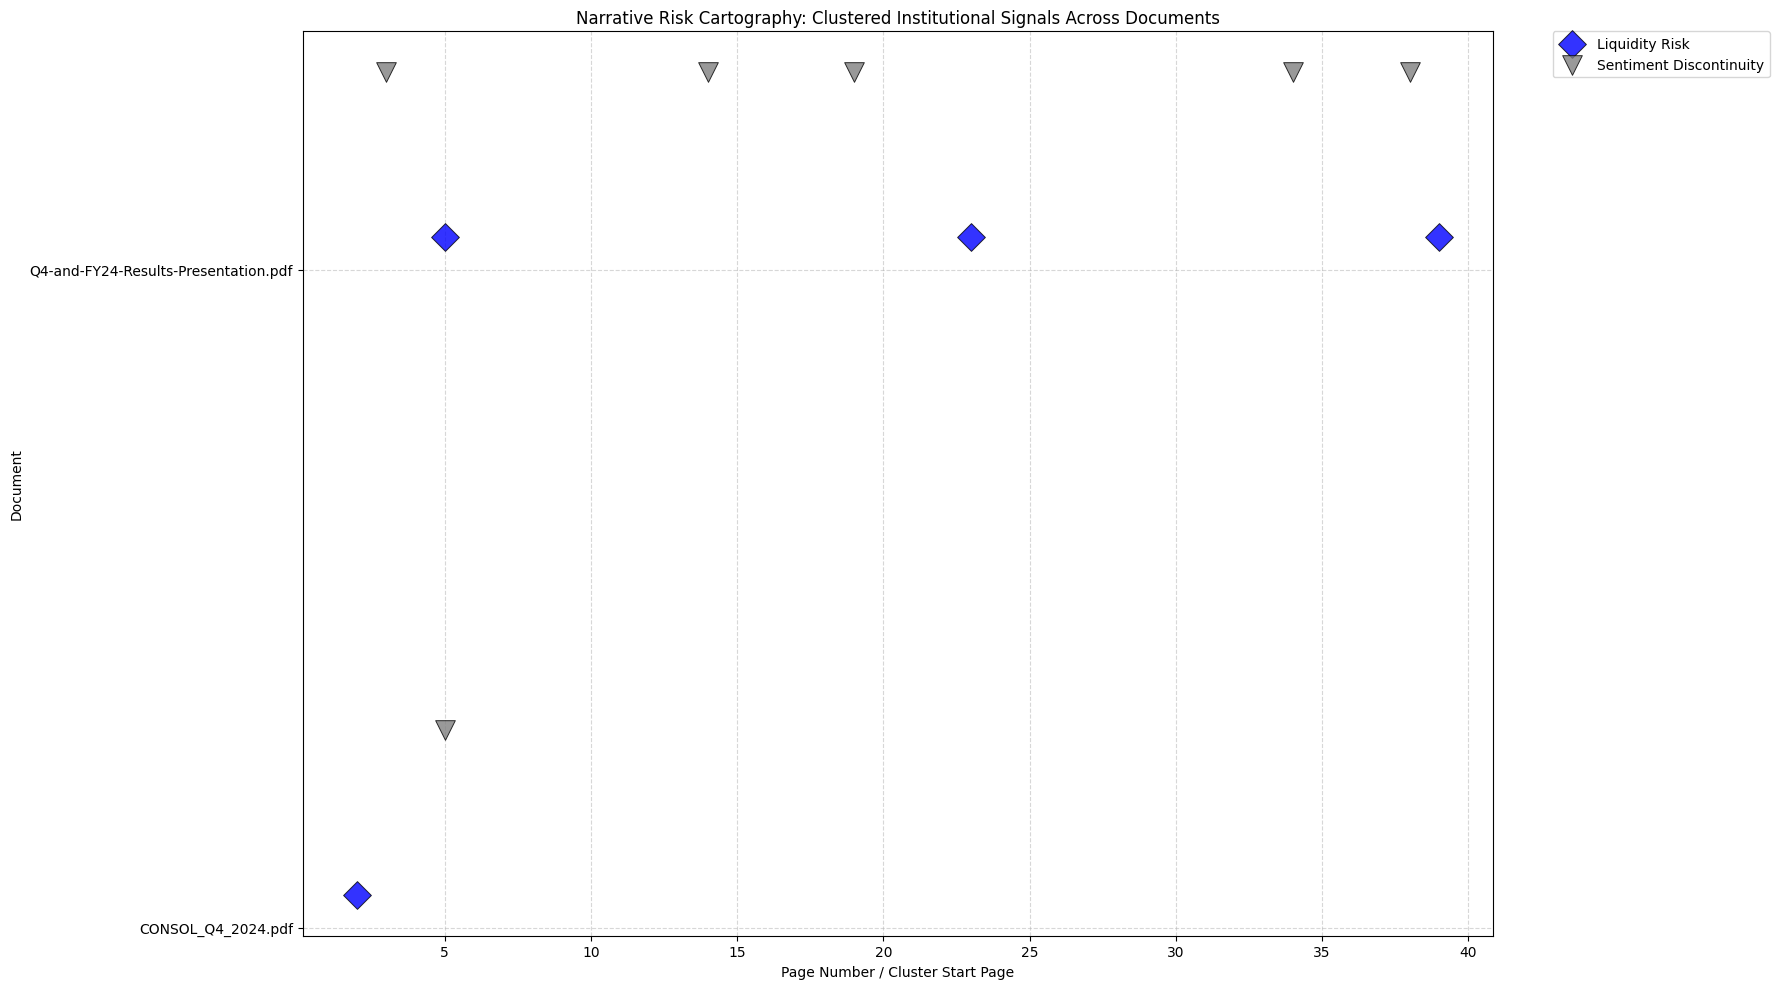

In [11]:
import numpy as np
import re
import nltk
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure NLTK data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# --- 1. Text Cleaning Function ---
# Robust cleaning to remove OCR noise, formatting, phone numbers, addresses, headers, and table artifacts.
def clean_text(text):
    # Remove common OCR and formatting artifacts
    text = re.sub(r'\n|\t|\r', ' ', text) # Newlines, tabs, carriage returns
    text = re.sub(r'\s+', ' ', text).strip() # Multiple spaces
    text = re.sub(r'Page \d+ of \d+', '', text, flags=re.IGNORECASE) # Page numbers
    text = re.sub(r'\b(?:DLF Limited|Embassy REIT|Q[1-4]FY[0-9]{2}|FY[0-9]{2}|FY[0-9]{4})\b', '', text, flags=re.IGNORECASE) # Common headers/footers

    # Remove phone numbers (common patterns) and addresses
    text = re.sub(r'\b\+?\d{1,3}[-.\s]?\(?\d{1,4}\)?[-.\s]?\d{1,4}[-.\s]?\d{1,9}\b', '', text) # Phone numbers
    # Simplified address removal - target patterns like street numbers and names, then cities/states (imperfect but better than nothing)
    text = re.sub(r'\b\d{1,5}\s[A-Za-z]+\s(?:Street|Road|Lane|Avenue|Marg|Rd|St|Ave|Ln)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?:Mumbai|Delhi|Bengaluru|Bangalore|Chennai|Kolkata|Hyderabad|Gurgaon|India)\b', '', text, flags=re.IGNORECASE) # Common Indian cities
    text = re.sub(r'PIN:\s*\d{6}\b', '', text, flags=re.IGNORECASE) # PIN codes

    # Remove table-like artifacts (e.g., multiple spaces, specific delimiters)
    text = re.sub(r'(?:\.{2,}|\-{2,}|\={2,}|\_{2,}|\*{2,})\s*(?:\.{2,}|\-{2,}|\={2,}|\_{2,}|\*{2,})', ' ', text) # Lines/separators
    text = re.sub(r'[\|][\s\-]*[\|]', ' ', text) # Table borders

    # Remove symbols and punctuation that are likely noise, keeping some for sentence structure
    text = re.sub(r'[^A-Za-z0-9\s.,!?%()-]', '', text) # Allow basic punctuation, numbers, and % (for percentages)

    # Additional cleaning for common disclaimers (often at end of reports)
    text = re.sub(r'This presentation contains forward-looking statements.*?\.', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'Disclaimer.*?(?:\.|\n)', '', text, flags=re.DOTALL | re.IGNORECASE)

    text = re.sub(r'\s+', ' ', text).strip() # Final pass to clean up spaces

    return text

# --- 2. New Thematic Keywords and Ontology ---
# Expanded and restructured ontology as per user's request
new_thematic_keywords = {
    "Financing & Refinancing Risk": [
        "debt maturity", "debt repayment", "refinance", "refinancing", "borrowing cost", "interest burden",
        "leverage", "debt service", "covenant pressure", "default risk", "financing risk", "loan-to-value",
        "cost of capital", "debt obligation", "credit rating", "fundraise", "equity dilution", "debt structure"
    ],
    "Liquidity & Cashflow Risk": [
        "liquidity position", "cash flow", "cashflow pressure", "working capital", "collections slowdown",
        "surplus cash", "cash generation", "free cash flow", "operating cash flow", "cash burn", "fund availability",
        "tenant payment", "receivables", "payables", "short-term obligation", "cash reserve"
    ],
    "Pricing Sustainability Risk": [
        "pricing strategy", "price appreciation", "margin sustainability", "cap rate", "valuation assumption",
        "yield compression", "market value", "rental yield", "luxury segment", "affordability threshold",
        "supply demand imbalance", "developer margin", "property valuation", "rental growth", "market rates"
    ],
    "Demand & Absorption Risk": [
        "booking slowdown", "weak demand", "absorption rate", "inventory overhang", "sales velocity",
        "launch pipeline", "affordability pressure", "buyer sentiment", "market sentiment", "vacancy rate",
        "leasing activity", "occupancy levels", "pre-leasing", "new sales", "sales pipeline"
    ],
    "Operational & Execution Risk": [
        "project delay", "construction bottleneck", "execution timeline", "regulatory approval",
        "environmental clearance", "land acquisition", "litigation risk", "cost overrun", "project cost",
        "supply chain disruption", "labour shortage", "material cost", "operational efficiency", "development risk",
        "occupancy risk", "leasing risk"
    ],
    "Governance & Disclosure Signals": [
        "forward-looking statement", "cautionary statement", "uncertainty disclosure", "audit observation",
        "contingent liability", "management commentary", "board resolution", "related party transaction",
        "regulatory non-compliance", "ethical concerns", "governance practices", "internal controls", "risk management framework"
    ]
}

# Helper to lemmatize keywords for better matching
def lemmatize_keywords(keywords_list):
    return [lemmatizer.lemmatize(word) for word in keywords_list]

# Pre-lemmatize all keywords for efficient matching
lemmatized_thematic_keywords = {
    theme: lemmatize_keywords(keywords) for theme, keywords in new_thematic_keywords.items()
}

# --- 3. Redesigned Helper Function for Summary Extraction ---
def extract_summary_refined(page_text, triggering_keywords, signal_type, sentiment_label=None, sentiment_score=None, window_size=3):
    sentences = sent_tokenize(page_text)
    best_sentences = []
    matched_indices = set()

    # Prioritize sentences containing the triggering keywords and their vicinity
    for i, sentence in enumerate(sentences):
        for keyword in triggering_keywords:
            if re.search(r'\b' + re.escape(keyword) + r'\b', sentence, re.IGNORECASE):
                # Add the matching sentence and its neighbors within the window
                for j in range(max(0, i - window_size), min(len(sentences), i + window_size + 1)):
                    matched_indices.add(j)
                break

    # Collect unique sentences based on matched indices, maintaining order
    for idx in sorted(list(matched_indices)):
        best_sentences.append(sentences[idx])

    # Fallback for sentiment drops if no specific keywords identified
    if not best_sentences and (signal_type == "Sentiment Drop" or sentiment_label == "negative"):
        negative_sentiment_terms = ["decline", "fall", "decrease", "loss", "worsen", "challenge", "difficult", "weak", "lower", "reduce"]
        for term in negative_sentiment_terms:
            for sentence in sentences:
                if re.search(r'\b' + re.escape(term) + r'\b', sentence, re.IGNORECASE):
                    best_sentences.append(sentence)
                    if len(best_sentences) >= 3: break # Limit sentences
            if len(best_sentences) >= 3: break
        best_sentences = list(dict.fromkeys(best_sentences))[:3]

    if not best_sentences:
        best_sentences = sentences[:2] # Default to first two sentences

    return " ".join(best_sentences).replace('\n', ' ').strip()[:300] + '...' if best_sentences else ""

# --- 4. Signal Detection Logic with Severity and Confidence Scoring ---

signals_detected_refined = []

# Thresholds (can be made configurable)
SENTIMENT_DROP_STD_FACTOR = 1.0
SHARP_SENTIMENT_DROP_THRESHOLD = 0.10
RISK_COUNT_PERCENTILE_THRESHOLD = 90
RISK_COUNT_ABOVE_AVG_STD_FACTOR = 1.0
THEMATIC_KEYWORD_MIN_COUNT = 2 # Minimum unique keywords from a theme to trigger

# Proximity window for related terms (sentences)
PROXIMITY_WINDOW_SENTENCES = 3

for doc_name in all_raw_texts_df['document'].unique(): # Use all_raw_texts_df for full text initially
    doc_df_full = all_raw_texts_df[all_raw_texts_df['document'] == doc_name].copy()
    doc_df_full['cleaned_text'] = doc_df_full['text'].apply(clean_text)

    # Merge with sentiment/risk data from final_comparison_df for scoring
    doc_df = pd.merge(
        doc_df_full,
        final_comparison_df[final_comparison_df['document'] == doc_name][['page', 'label', 'score', 'risk_count']],
        on='page',
        how='left'
    )

    # Fill NA for pages where sentiment/risk data might be missing (e.g. only text was found originally)
    doc_df[['label', 'score', 'risk_count']] = doc_df[['label', 'score', 'risk_count']].fillna({'label': 'N/A', 'score': 0, 'risk_count': 0})

    # Calculate document-level stats for relative thresholds
    valid_sentiment_scores = doc_df[~doc_df['label'].isin(['ERROR', 'N/A'])]['score']
    doc_avg_sentiment = valid_sentiment_scores.mean() if not valid_sentiment_scores.empty else 0
    doc_std_sentiment = valid_sentiment_scores.std() if len(valid_sentiment_scores) > 1 else 0

    doc_avg_risk_count = doc_df['risk_count'].mean()
    doc_std_risk_count = doc_df['risk_count'].std() if len(doc_df) > 1 else 0
    risk_90th_percentile = doc_df['risk_count'].quantile(RISK_COUNT_PERCENTILE_THRESHOLD / 100) if not doc_df.empty else 0

    doc_df['prev_score'] = doc_df['score'].shift(1)

    for idx, row in doc_df.iterrows():
        page = row['page']
        cleaned_text = row['cleaned_text']
        raw_text = row['text'] # Use raw text for summary extraction to preserve context
        sentiment_score = row['score']
        sentiment_label = row['label']
        risk_count = row['risk_count']
        prev_score = row['prev_score']

        page_signals = []

        # Helper for scoring
        def calculate_score_metrics(matched_keywords, current_sentiment_score, doc_avg_sentiment, doc_std_sentiment):
            severity = "Low"
            confidence = "Low"

            keyword_density = len(matched_keywords) / (len(cleaned_text.split()) + 1e-6) # Avoid division by zero

            # Severity based on keyword count and sentiment context
            if len(matched_keywords) >= THEMATIC_KEYWORD_MIN_COUNT + 1:
                severity = "Moderate"
            if len(matched_keywords) >= THEMATIC_KEYWORD_MIN_COUNT + 3:
                severity = "High"

            if sentiment_label == 'negative' and current_sentiment_score < (doc_avg_sentiment - 0.5 * doc_std_sentiment):
                if severity == "Low": severity = "Moderate"
                elif severity == "Moderate": severity = "High"

            # Confidence based on keyword density and sentiment deviation
            if keyword_density > 0.005: # e.g., 0.5% of words are keywords
                confidence = "Moderate"
            if keyword_density > 0.01: # e.g., 1% of words are keywords
                confidence = "High"

            # Additional confidence boost for sentiment deviation if relevant
            if sentiment_label != 'ERROR' and sentiment_label != 'N/A' and doc_std_sentiment > 0:
                sentiment_dev = (doc_avg_sentiment - current_sentiment_score) / doc_std_sentiment
                if sentiment_dev > 1.0: # More than 1 STD below avg
                    if confidence == "Low": confidence = "Moderate"
                    elif confidence == "Moderate": confidence = "High"

            return severity, confidence

        # --- Thematic Signal Detection ---
        for theme, keywords in new_thematic_keywords.items():
            found_keywords_on_page = []
            lemmas_on_page = [lemmatizer.lemmatize(word.lower()) for word in cleaned_text.split()]

            for original_keyword, lemmatized_keyword in zip(new_thematic_keywords[theme], lemmatized_thematic_keywords[theme]):
                # Use regex for original keyword for exact matches (e.g. "cash flow" as phrase)
                if re.search(r'\b' + re.escape(original_keyword) + r'\b', cleaned_text, re.IGNORECASE):
                    found_keywords_on_page.append(original_keyword)
                # Also check for lemmatized versions of individual words if not a phrase match
                elif ' ' not in original_keyword and lemmatized_keyword in lemmas_on_page:
                     found_keywords_on_page.append(original_keyword)

            unique_found_keywords = list(set(found_keywords_on_page))

            if len(unique_found_keywords) >= THEMATIC_KEYWORD_MIN_COUNT:
                signal_severity, signal_confidence = calculate_score_metrics(unique_found_keywords, sentiment_score, doc_avg_sentiment, doc_std_sentiment)
                summary = extract_summary_refined(raw_text, unique_found_keywords, theme)

                page_signals.append({
                    'Document': doc_name,
                    'Page': page,
                    'Signal Type': theme, # Use the broad theme as signal type for now
                    'Theme': theme, # Theme and Signal Type are the same in this design
                    'Severity': signal_severity,
                    'Confidence': signal_confidence,
                    'Extract Summary': summary
                })

        # --- Sentiment Discontinuity (Sentiment Drop) ---
        sentiment_triggered = False
        if sentiment_label != 'ERROR' and sentiment_label != 'N/A' and doc_std_sentiment > 0:
            # Trigger 1: Significantly below document average
            if sentiment_score < (doc_avg_sentiment - SENTIMENT_DROP_STD_FACTOR * doc_std_sentiment):
                signal_severity, signal_confidence = calculate_score_metrics([], sentiment_score, doc_avg_sentiment, doc_std_sentiment)
                summary = extract_summary_refined(raw_text, [], "Sentiment Drop", sentiment_label=sentiment_label, sentiment_score=sentiment_score)
                page_signals.append({
                    'Document': doc_name,
                    'Page': page,
                    'Signal Type': 'Sentiment Discontinuity',
                    'Theme': 'General Sentiment',
                    'Severity': signal_severity,
                    'Confidence': signal_confidence,
                    'Extract Summary': summary
                })
                sentiment_triggered = True
            # Trigger 2: Sharp drop from previous page
            elif not sentiment_triggered and prev_score is not np.nan and \
                 (prev_score - sentiment_score) > SHARP_SENTIMENT_DROP_THRESHOLD:
                signal_severity, signal_confidence = calculate_score_metrics([], sentiment_score, doc_avg_sentiment, doc_std_sentiment)
                summary = extract_summary_refined(raw_text, [], "Sentiment Drop", sentiment_label=sentiment_label, sentiment_score=sentiment_score)
                page_signals.append({
                    'Document': doc_name,
                    'Page': page,
                    'Signal Type': 'Sentiment Discontinuity',
                    'Theme': 'General Sentiment',
                    'Severity': signal_confidence, # Use confidence here as proxy for strength
                    'Confidence': signal_confidence,
                    'Extract Summary': summary
                })

        signals_detected_refined.extend(page_signals)

# --- 5. Create Final Explanations DataFrame ---
final_explanation_table_refined = pd.DataFrame(signals_detected_refined)

# Process signal clusters and multi-page concentrations
if not final_explanation_table_refined.empty:
    # Sort to easily detect clusters
    final_explanation_table_refined = final_explanation_table_refined.sort_values(by=['Document', 'Page']).reset_index(drop=True)

    # Identify multi-page risk concentrations / repeated thematic clusters
    final_signals_processed = []
    current_cluster = []

    for i, row in final_explanation_table_refined.iterrows():
        if not current_cluster: # Start new cluster
            current_cluster.append(row)
        else:
            last_row = current_cluster[-1]
            # Check if current signal is part of the same document and consecutive page (or very close) with same theme
            is_consecutive_page = (row['Document'] == last_row['Document']) and (row['Page'] <= last_row['Page'] + PROXIMITY_WINDOW_SENTENCES) # allow some gap
            is_same_theme = (row['Theme'] == last_row['Theme'])

            if is_consecutive_page and is_same_theme: # Extend cluster
                current_cluster.append(row)
            else: # End previous cluster, start new one
                final_signals_processed.append(current_cluster)
                current_cluster = [row]

    if current_cluster: # Add the last cluster
        final_signals_processed.append(current_cluster)

    # Consolidate clusters into single signals with updated info
    final_output_rows = []
    for cluster in final_signals_processed:
        if len(cluster) == 1: # Isolated signal
            final_output_rows.append(cluster[0])
        else: # Clustered signal
            first_page = cluster[0]['Page']
            last_page = cluster[-1]['Page']
            document = cluster[0]['Document']
            theme = cluster[0]['Theme']

            # Aggregate severity and confidence
            severities = [s['Severity'] for s in cluster]
            confidences = [c['Confidence'] for c in cluster]

            # Simple aggregation: take max for now
            max_severity = "Low"
            if "Moderate" in severities: max_severity = "Moderate"
            if "High" in severities: max_severity = "High"

            max_confidence = "Low"
            if "Moderate" in confidences: max_confidence = "Moderate"
            if "High" in confidences: max_confidence = "High"

            # Combine summaries for the cluster
            combined_summary = " ".join(list(dict.fromkeys([s['Extract Summary'] for s in cluster])))
            combined_summary = (combined_summary[:400] + '...') if len(combined_summary) > 400 else combined_summary

            signal_type = f"{theme} Cluster ({first_page}-{last_page})"
            if theme == 'Sentiment Discontinuity': # Sentiment clusters are still discontinuities
                signal_type = f"Sentiment Discontinuity Cluster ({first_page}-{last_page})"

            final_output_rows.append({
                'Document': document,
                'Page': f"{first_page}-{last_page}", # Page range
                'Signal Type': signal_type,
                'Theme': theme,
                'Severity': max_severity,
                'Confidence': max_confidence,
                'Extract Summary': combined_summary
            })

    final_explanation_table_refined = pd.DataFrame(final_output_rows)


# Reorder and select final columns
final_explanation_table_refined = final_explanation_table_refined[[
    'Document', 'Page', 'Signal Type', 'Theme', 'Severity', 'Confidence', 'Extract Summary'
]]

print("\n--- Redesigned Explainable Narrative Signal Framework ---")
display(final_explanation_table_refined)

# --- 6. Improved Visualization Logic (Narrative Risk Cartography) ---

if not final_explanation_table_refined.empty:
    plt.figure(figsize=(18, 10))

    # Define markers and colors for new Signal Types/Themes
    # Map broad themes to consistent colors/markers
    theme_styles = {
        "Financing & Refinancing Risk": {'marker': 's', 'color': 'red', 'label': 'Financing Risk'},
        "Liquidity & Cashflow Risk": {'marker': 'D', 'color': 'blue', 'label': 'Liquidity Risk'},
        "Pricing Sustainability Risk": {'marker': 'o', 'color': 'green', 'label': 'Pricing Risk'},
        "Demand & Absorption Risk": {'marker': '^', 'color': 'purple', 'label': 'Demand Risk'},
        "Operational & Execution Risk": {'marker': 'X', 'color': 'orange', 'label': 'Operational Risk'},
        "Governance & Disclosure Signals": {'marker': 'P', 'color': 'brown', 'label': 'Governance Signals'},
        "General Sentiment": {'marker': 'v', 'color': 'grey', 'label': 'Sentiment Discontinuity'}
    }

    # Get unique documents and assign a numerical index for plotting on the y-axis
    unique_documents_viz = final_explanation_table_refined['Document'].unique()
    doc_y_map_viz = {doc: i for i, doc in enumerate(unique_documents_viz)}

    # Plotting signals for each document
    for i, doc_name in enumerate(unique_documents_viz):
        doc_signals_viz = final_explanation_table_refined[final_explanation_table_refined['Document'] == doc_name]
        y_base = doc_y_map_viz[doc_name] # Base y-level for the current document

        for theme, style in theme_styles.items():
            subset = doc_signals_viz[doc_signals_viz['Theme'] == theme]

            if not subset.empty:
                # Handle page ranges for plotting: take the start of the range or single page number
                plot_pages = []
                for page_val in subset['Page']:
                    if isinstance(page_val, str) and '-' in page_val:
                        plot_pages.append(int(page_val.split('-')[0])) # Use start page for cluster
                    else:
                        plot_pages.append(int(page_val))

                plt.scatter(
                    plot_pages,
                    np.full(len(subset), y_base + (0.05 * list(theme_styles.keys()).index(theme))), # Offset for overlapping signals
                    marker=style['marker'],
                    color=style['color'],
                    s=200, # Larger size
                    label=style['label'] if i == 0 else "", # Label only once for legend
                    alpha=0.8,
                    edgecolors='black', # Add edge for clarity
                    linewidths=0.7,
                    zorder=2
                )

    plt.yticks(list(doc_y_map_viz.values()), list(doc_y_map_viz.keys()), rotation=0)
    plt.xlabel('Page Number / Cluster Start Page')
    plt.ylabel('Document')
    plt.title('Narrative Risk Cartography: Clustered Institutional Signals Across Documents')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()
else:
    print("No signals detected to visualize.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



--- Final Governance-Aware Institutional Narrative Interpretation Framework ---


,Document,Page/Cluster,Narrative Category,Theme,Direction,Severity,Confidence,Rationale,Extract Summary
0,CONSOL_Q4_2024.pdf,1,Financing Supportive Narrative,Financing & Refinancing,Strengthening / Supportive / Resilient / Stable,Informational,Moderate,"Triggered by keywords: capital, equity. Keywor...","Office: Shopping Mall, 3rd Floor, Arjun Marg, ..."
1,CONSOL_Q4_2024.pdf,1,Financing Structure Discussion,Financing & Refinancing,Monitoring / Neutral / Tracking,Elevated Attention,High,"Triggered by keywords: cost, of, equity, inter...","DLF Limited Regd. Office: Shopping Mall, 3rd F..."
2,CONSOL_Q4_2024.pdf,1,Financing Stress Signal,Financing & Refinancing,Weakening / Constrained / Slowing / Caution,Elevated Attention,High,"Triggered by keywords: costs, financial, to, c...","DLF Limited Regd. Office: Shopping Mall, 3rd F..."
3,CONSOL_Q4_2024.pdf,1,Liquidity Strengthening Narrative,Liquidity & Cashflow,Strengthening / Supportive / Resilient / Stable,Informational,Moderate,"Triggered by keywords: net, capital. Keyword d...","Office: Shopping Mall, 3rd Floor, Arjun Marg, ..."
4,CONSOL_Q4_2024.pdf,1,Liquidity Caution Signal,Liquidity & Cashflow,Weakening / Constrained / Slowing / Caution,Elevated Attention,High,"Triggered by keywords: for, to, capital. Keywo...","DLF Limited Regd. Office: Shopping Mall, 3rd F..."
...,...,...,...,...,...,...,...,...,...
287,Q4-and-FY24-Results-Presentation.pdf,42,Operational Execution Monitoring,Operational & Execution,Monitoring / Neutral / Tracking,Informational,High,"Triggered by keywords: cost, risk. Keyword den...",Disclaimer This presentation contains certain ...
288,Q4-and-FY24-Results-Presentation.pdf,42,Operational Risk Signal,Operational & Execution,Weakening / Constrained / Slowing / Caution,Monitoring,High,"Triggered by keywords: cost, overrun. Keyword ...",Disclaimer This presentation contains certain ...
289,Q4-and-FY24-Results-Presentation.pdf,42,Governance Disclosure Cluster,Governance & Disclosure,Monitoring / Neutral / Tracking,Monitoring,High,"Triggered by keywords: update, risk, related. ...",Disclaimer This presentation contains certain ...
290,Q4-and-FY24-Results-Presentation.pdf,42,Regulatory Uncertainty Signal,Governance & Disclosure,Weakening / Constrained / Slowing / Caution,Monitoring,High,"Triggered by keywords: uncertainty, related. K...",Disclaimer This presentation contains certain ...


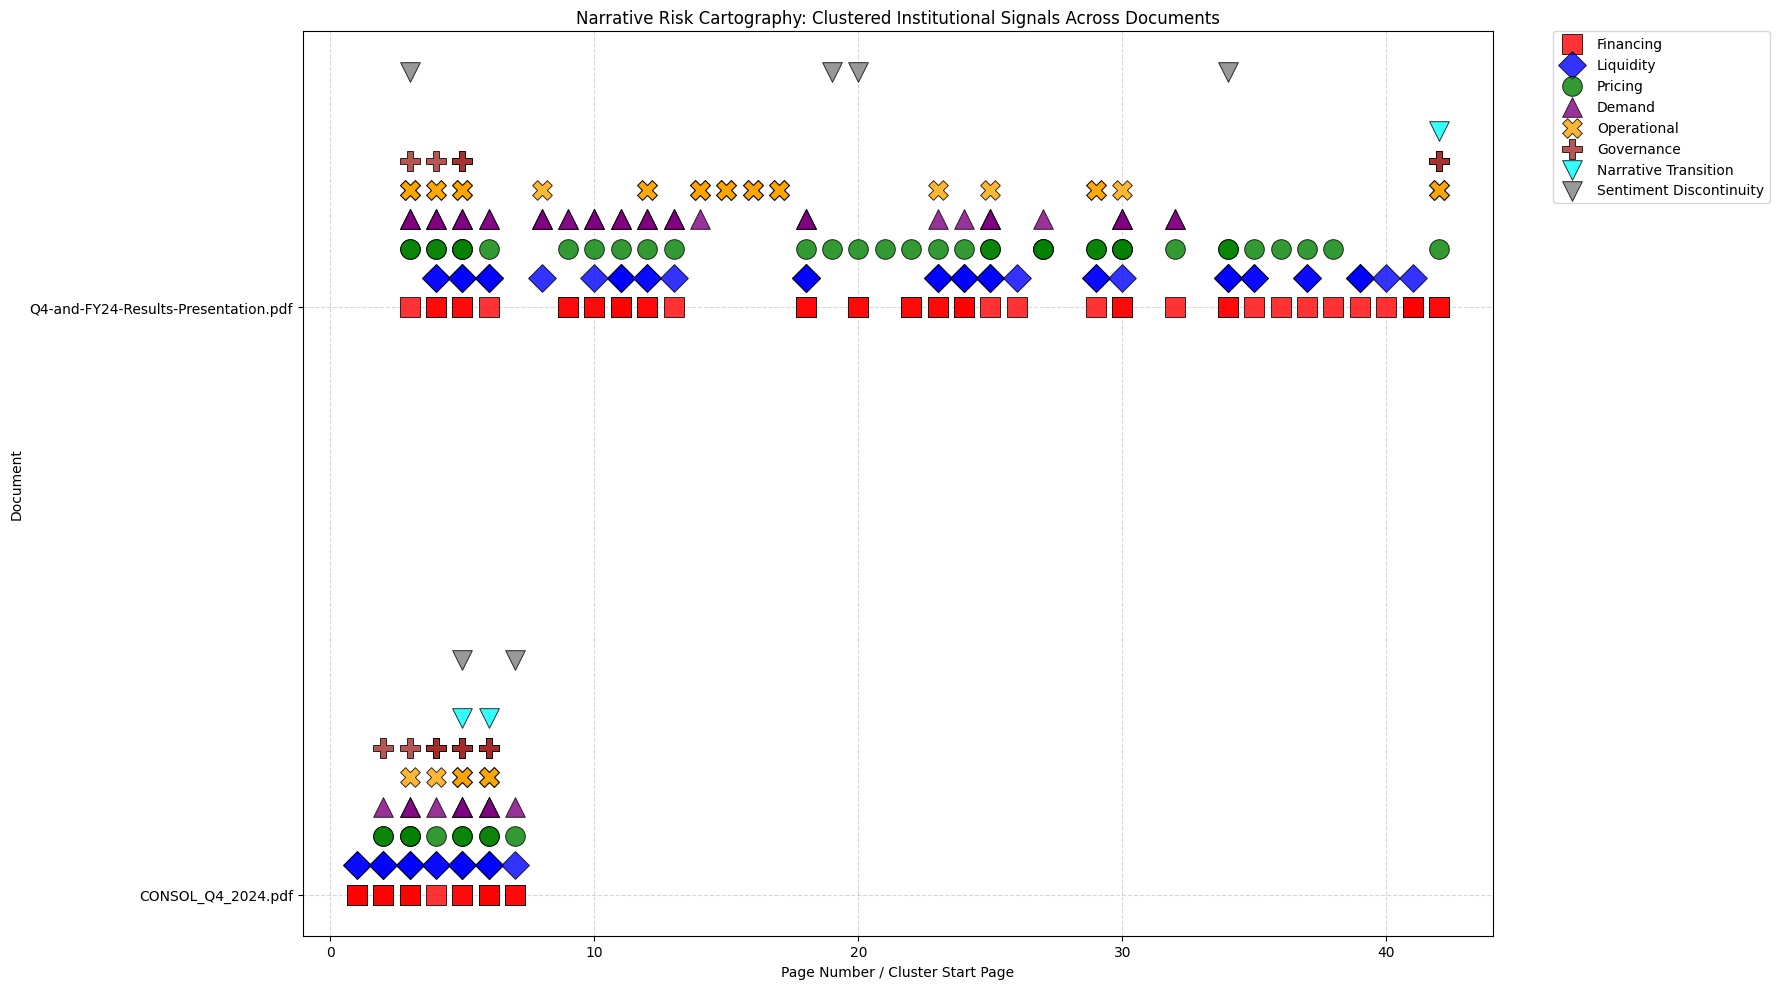

In [14]:
import numpy as np
import re
import nltk
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure NLTK data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# --- 1. Text Cleaning Function (reused from previous implementation) ---
def clean_text(text):
    # Remove common OCR and formatting artifacts
    text = re.sub(r'\n|\t|\r', ' ', text) # Newlines, tabs, carriage returns
    text = re.sub(r'\s+', ' ', text).strip() # Multiple spaces
    text = re.sub(r'Page \d+ of \d+', '', text, flags=re.IGNORECASE) # Page numbers
    text = re.sub(r'\b(?:DLF Limited|Embassy REIT|Q[1-4]FY[0-9]{2}|FY[0-9]{2}|FY[0-9]{4})\b', '', text, flags=re.IGNORECASE) # Common headers/footers

    # Remove phone numbers (common patterns) and addresses
    text = re.sub(r'\b\+?\d{1,3}[-.\s]?\(?\d{1,4}\)?[-.\s]?\d{1,4}[-.\s]?\d{1,9}\b', '', text) # Phone numbers
    # Simplified address removal - target patterns like street numbers and names, then cities/states (imperfect but better than nothing)
    text = re.sub(r'\b\d{1,5}\s[A-Za-z]+\s(?:Street|Road|Lane|Avenue|Marg|Rd|St|Ave|Ln)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?:Mumbai|Delhi|Bengaluru|Bangalore|Chennai|Kolkata|Hyderabad|Gurgaon|India)\b', '', text, flags=re.IGNORECASE) # Common Indian cities
    text = re.sub(r'PIN:\s*\d{6}\b', '', text, flags=re.IGNORECASE) # PIN codes

    # Remove table-like artifacts (e.g., multiple spaces, specific delimiters)
    text = re.sub(r'(?:\.{2,}|\-{2,}|\={2,}|\_{2,}|\*{2,})\s*(?:\.{2,}|\-{2,}|\={2,}|\_{2,}|\*{2,})', ' ', text)
    text = re.sub(r'[\|][\s\-]*[\|]', ' ', text) # Table borders

    # Remove symbols and punctuation that are likely noise, keeping some for sentence structure
    text = re.sub(r'[^A-Za-z0-9\s.,!?%()-]', '', text) # Allow basic punctuation, numbers, and % (for percentages)

    # Additional cleaning for common disclaimers (often at end of reports)
    text = re.sub(r'This presentation contains forward-looking statements.*?.', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'Disclaimer.*?(?:.|\n)', '', text, flags=re.DOTALL | re.IGNORECASE)

    text = re.sub(r'\s+', ' ', text).strip() # Final pass to clean up spaces

    return text

# --- 2. Redesigned Ontology with Resilience/Monitoring/Stress (Tasks 1, 2, 3) ---
# New comprehensive ontology structure
narrative_ontology = {
    "Financing & Refinancing": {
        "Resilience": [
            "successful refinancing", "debt reduction", "strengthened balance sheet", "favorable borrowing terms",
            "prudent debt management", "strong credit rating", "diversified funding sources", "equity infusion",
            "low leverage", "robust capital structure", "supportive lenders", "long-term debt maturity profile"
        ],
        "Monitoring": [
            "refinancing discussions", "debt maturity profile", "covenant compliance", "leverage ratios",
            "cost of capital analysis", "funding strategy", "debt servicing capacity", "interest rate hedging",
            "credit facility utilization", "capital expenditure plans", "dividend policy", "potential equity raise"
        ],
        "Stress": [
            "refinancing pressure", "debt repayment challenge", "covenant breach", "increased borrowing costs",
            "loan default", "liquidity crunch", "high leverage risk", "rating downgrade", "limited access to capital",
            "foreclosure", "debt restructuring", "asset sales", "financial distress", "insolvency concern"
        ]
    },
    "Liquidity & Cashflow": {
        "Resilience": [
            "strong operating cash flow", "healthy collections", "improving net cash position", "ample liquidity",
            "robust cash generation", "significant cash reserves", "positive cash conversion cycle", "strong balance sheet liquidity",
            "optimised working capital", "prudent cash management"
        ],
        "Monitoring": [
            "liquidity monitoring", "cash flow forecasting", "working capital management", "collections tracking",
            "cash conservation measures", "debt service coverage ratio", "receivables aging", "payables management",
            "cash burn rate analysis", "fund deployment strategy", "contingency planning"
        ],
        "Stress": [
            "collections slowdown", "cash flow pressure", "liquidity shortfall", "negative operating cash flow",
            "working capital deficit", "constrained cash position", "inability to meet obligations", "high cash burn",
            "delayed payments", "tight credit conditions", "capital calls", "asset sales for liquidity"
        ]
    },
    "Pricing Sustainability": {
        "Resilience": [
            "strong rental growth", "stable pricing", "yield expansion", "robust valuation", "premium pricing",
            "market leadership pricing", "sustainable margins", "high occupancy rates at favorable rents",
            "strong demand leading to price stability", "positive market outlook"
        ],
        "Monitoring": [
            "pricing strategy review", "market rate analysis", "cap rate trends", "valuation assumptions",
            "yield sensitivity", "rental yield analysis", "affordability sensitivity", "competitive pricing assessment",
            "supply-demand dynamics", "market sentiment tracking", "discounting levels"
        ],
        "Stress": [
            "pricing sustainability concern", "yield compression", "valuation uncertainty", "rental decline",
            "market downturn", "significant discounts", "price erosion", "over-supply impact", "declining property values",
            "buyer resistance", "high inventory overhang", "softening market"
        ]
    },
    "Demand & Absorption": {
        "Resilience": [
            "strong demand", "healthy absorption", "high pre-leasing rates", "robust sales velocity",
            "low vacancy rates", "improving occupancy", "strategic location demand", "successful project launches",
            "positive buyer sentiment", "expanding customer base", "strong market fundamentals"
        ],
        "Monitoring": [
            "absorption tracking", "demand forecasting", "sales pipeline analysis", "occupancy rate monitoring",
            "vacancy trends", "pre-leasing activity", "market research on buyer behavior", "new launch performance",
            "regional demand indicators", "customer feedback analysis"
        ],
        "Stress": [
            "weak absorption", "booking slowdown", "declining sales velocity", "rising vacancy rates",
            "high inventory levels", "poor project performance", "negative buyer sentiment", "demand erosion",
            "over-supply conditions", "market saturation", "economic slowdown impact"
        ]
    },
    "Operational & Execution": {
        "Resilience": [
            "efficient project execution", "on-time delivery", "cost control", "strong operational performance",
            "effective risk management", "streamlined processes", "experienced management team", "strong supply chain",
            "successful project completion", "robust internal controls"
        ],
        "Monitoring": [
            "execution tracking", "project timeline management", "cost control monitoring", "regulatory compliance review",
            "environmental risk assessment", "litigation exposure analysis", "supply chain oversight", "staffing levels analysis",
            "operational efficiency metrics", "quality control checks"
        ],
        "Stress": [
            "project delay", "cost overrun", "operational disruption", "regulatory non-compliance",
            "litigation exposure", "supply chain issues", "labor shortage", "material cost increase",
            "poor execution", "quality concerns", "environmental liabilities", "accidents", "fraud"
        ]
    },
    "Governance & Disclosure": {
        "Resilience": [
            "transparent disclosures", "strong corporate governance", "ethical practices", "robust internal controls",
            "positive audit outcomes", "shareholder protection", "board independence", "regulatory adherence",
            "effective risk oversight", "clear communication", "stakeholder engagement"
        ],
        "Monitoring": [
            "disclosure review", "governance practices assessment", "audit observations tracking",
            "regulatory changes monitoring", "legal proceedings update", "contingent liability assessment",
            "related party transaction review", "board effectiveness review", "shareholder engagement efforts",
            "risk management framework assessment"
        ],
        "Stress": [
            "regulatory uncertainty", "litigation threat", "adverse audit opinion", "governance concerns",
            "disclosure gaps", "investigation", "sanctions", "fines", "shareholder activism", "board disputes",
            "ethical lapse", "related party transaction concerns", "non-compliance"
        ]
    }
}

# Additional specific narrative types not falling neatly into Resilience/Monitoring/Stress categories
special_narratives = {
    "Narrative Transition": [
        "however", "on the other hand", "nevertheless", "but", "yet", "conversely", "despite this",
        "while", "although", "in contrast", "meanwhile", "subsequently", "going forward"
    ],
    "Strategic Expansion Narrative": [
        "growth initiatives", "market expansion", "new projects", "portfolio diversification", "acquisition strategy",
        "investment pipeline", "geographic expansion", "new business segments", "capacity addition", "innovation drive"
    ]
}

# Map for richer Narrative Categories (Task 2)
category_mapping = {
    "Financing & Refinancing_Resilience": "Financing Supportive Narrative",
    "Financing & Refinancing_Monitoring": "Financing Structure Discussion",
    "Financing & Refinancing_Stress": "Financing Stress Signal",
    "Liquidity & Cashflow_Resilience": "Liquidity Strengthening Narrative",
    "Liquidity & Cashflow_Monitoring": "Liquidity Monitoring",
    "Liquidity & Cashflow_Stress": "Liquidity Caution Signal",
    "Pricing Sustainability_Resilience": "Pricing Sustainable Narrative",
    "Pricing Sustainability_Monitoring": "Pricing Sustainability Discussion",
    "Pricing Sustainability_Stress": "Pricing Caution Signal",
    "Demand & Absorption_Resilience": "Demand Resilience Narrative",
    "Demand & Absorption_Monitoring": "Demand Tracking Narrative",
    "Demand & Absorption_Stress": "Demand Weakening Signal",
    "Operational & Execution_Resilience": "Operational Stability Narrative",
    "Operational & Execution_Monitoring": "Operational Execution Monitoring",
    "Operational & Execution_Stress": "Operational Risk Signal",
    "Governance & Disclosure_Resilience": "Governance Best Practice",
    "Governance & Disclosure_Monitoring": "Governance Disclosure Cluster",
    "Governance & Disclosure_Stress": "Regulatory Uncertainty Signal", # Broader for stress
    "Narrative Transition": "Narrative Transition",
    "Strategic Expansion Narrative": "Strategic Expansion Narrative",
    "Sentiment Discontinuity": "Sentiment Discontinuity",
    "Risk Spike": "General Risk Spike" # Fallback if specific themes not matched
}

# Pre-lemmatize all keywords for efficient matching
lemmatized_narrative_ontology = {}
for main_theme, sub_themes in narrative_ontology.items():
    lemmatized_narrative_ontology[main_theme] = {}
    for sub_theme, keywords in sub_themes.items():
        lemmatized_narrative_ontology[main_theme][sub_theme] = [lemmatizer.lemmatize(word) for word in keywords]

lemmatized_special_narratives = {
    cat: [lemmatizer.lemmatize(word) for word in keywords] for cat, keywords in special_narratives.items()
}

# --- 3. Refined Helper Function for Summary Extraction (reused) ---
def extract_summary_refined(page_text, triggering_keywords, signal_type, sentiment_label=None, sentiment_score=None, window_size=3):
    sentences = sent_tokenize(page_text)
    best_sentences = []
    matched_indices = set()

    # Prioritize sentences containing the triggering keywords and their vicinity
    for i, sentence in enumerate(sentences):
        for keyword in triggering_keywords:
            if re.search(r'\b' + re.escape(keyword) + r'\b', sentence, re.IGNORECASE):
                # Add the matching sentence and its neighbors within the window
                for j in range(max(0, i - window_size), min(len(sentences), i + window_size + 1)):
                    matched_indices.add(j)
                break

    # Collect unique sentences based on matched indices, maintaining order
    for idx in sorted(list(matched_indices)):
        best_sentences.append(sentences[idx])

    # Fallback for sentiment drops if no specific keywords identified
    if not best_sentences and (signal_type == "Sentiment Discontinuity" or sentiment_label == "negative"):
        negative_sentiment_terms = ["decline", "fall", "decrease", "loss", "worsen", "challenge", "difficult", "weak", "lower", "reduce"]
        for term in negative_sentiment_terms:
            for sentence in sentences:
                if re.search(r'\b' + re.escape(term) + r'\b', sentence, re.IGNORECASE):
                    best_sentences.append(sentence)
                    if len(best_sentences) >= 3: break # Limit sentences
            if len(best_sentences) >= 3: break
        best_sentences = list(dict.fromkeys(best_sentences))[:3]

    if not best_sentences:
        best_sentences = sentences[:2] # Default to first two sentences

    return " ".join(best_sentences).replace('\n', ' ').strip()[:300] + '...' if best_sentences else ""

# --- 4. Signal Detection Logic with Direction, Severity, Confidence, and Rationale (Tasks 2, 3, 5, 6, 9) ---

signals_detected_final = []

# Thresholds (can be made configurable)
SENTIMENT_DROP_STD_FACTOR = 1.0
SHARP_SENTIMENT_DROP_THRESHOLD = 0.10
THEMATIC_KEYWORD_MIN_COUNT = 2 # Minimum unique keywords from a theme to trigger
PROXIMITY_WINDOW_SENTENCES = 3

# Severity Mapping (Task 5)
SEVERITY_LEVELS = {
    "Low": "Informational",
    "Moderate": "Monitoring",
    "High": "Elevated Attention",
    "Critical": "Governance Escalation Candidate" # Used for high stress/governance issues
}

# Direction Mapping (Task 3)
DIRECTION_MAPPING = {
    "Resilience": "Strengthening / Supportive / Resilient / Stable",
    "Monitoring": "Monitoring / Neutral / Tracking",
    "Stress": "Weakening / Constrained / Slowing / Caution"
}

# Combined risk_words from previous implementation, for general risk spikes/density
risk_words_general = [
    "vacancy", "liquidity", "uncertainty", "risk", "slowdown", "headwinds",
    "debt", "macro", "volatility", "concern", "pressure", "challenge", "impact"
]

def calculate_score_metrics_and_rationale(matched_keywords, current_sentiment_score, doc_avg_sentiment, doc_std_sentiment, text_length_words, signal_type, found_keywords_original):
    severity_raw = "Low"
    confidence_raw = "Low"
    rationale_parts = []

    keyword_density = len(matched_keywords) / (text_length_words + 1e-6)

    # Severity based on keyword count and sentiment context
    if len(matched_keywords) >= THEMATIC_KEYWORD_MIN_COUNT + 1:
        severity_raw = "Moderate"
    if len(matched_keywords) >= THEMATIC_KEYWORD_MIN_COUNT + 3 or \
       ("Governance & Disclosure" in signal_type and len(matched_keywords) >= THEMATIC_KEYWORD_MIN_COUNT + 2):
        severity_raw = "High"
    if "Stress" in signal_type or "Caution" in signal_type or "Risk Signal" in signal_type or "Regulatory Uncertainty" in signal_type:
        if severity_raw == "Low": severity_raw = "Moderate"
        elif severity_raw == "Moderate": severity_raw = "High"

    # Confidence based on keyword density and sentiment deviation
    if keyword_density > 0.003:
        confidence_raw = "Moderate"
    if keyword_density > 0.008:
        confidence_raw = "High"

    # Sentiment deviation impact on severity/confidence
    if doc_std_sentiment > 0 and current_sentiment_score < (doc_avg_sentiment - 0.75 * doc_std_sentiment): # More than 0.75 STD below avg
        if confidence_raw == "Low": confidence_raw = "Moderate"
        elif confidence_raw == "Moderate": confidence_raw = "High"
        if severity_raw == "Low": severity_raw = "Moderate"
        elif severity_raw == "Moderate": severity_raw = "High"

    # Construct Rationale (Task 9)
    rationale_parts.append(f"Triggered by keywords: {', '.join(found_keywords_original)}. ")
    rationale_parts.append(f"Keyword density: {keyword_density:.2%}. ")

    if doc_std_sentiment > 0:
        sentiment_dev = (current_sentiment_score - doc_avg_sentiment) / doc_std_sentiment
        rationale_parts.append(f"Sentiment deviation from document average: {sentiment_dev:.2f} STD. ")

    # Final Severity Mapping (Task 5)
    final_severity = SEVERITY_LEVELS.get(severity_raw, severity_raw)

    # For 'Governance & Disclosure Stress' with high confidence/severity, elevate to 'Governance Escalation Candidate'
    if ("Governance & Disclosure" in signal_type and "Stress" in signal_type) and (confidence_raw == "High" or final_severity == "Elevated Attention"):
        final_severity = "Governance Escalation Candidate"
        rationale_parts.append("Elevated to Governance Escalation Candidate due to critical theme and high confidence/severity. ")

    return final_severity, confidence_raw, "".join(rationale_parts)

for doc_name in all_raw_texts_df['document'].unique(): # Use all_raw_texts_df for full text initially
    doc_df_full = all_raw_texts_df[all_raw_texts_df['document'] == doc_name].copy()
    doc_df_full['cleaned_text'] = doc_df_full['text'].apply(clean_text)

    # Merge with sentiment/risk data from final_comparison_df for scoring
    doc_df = pd.merge(
        doc_df_full,
        final_comparison_df[final_comparison_df['document'] == doc_name][['page', 'label', 'score', 'risk_count']],
        on='page',
        how='left'
    )

    # Fill NA for pages where sentiment/risk data might be missing (e.g. only text was found originally)
    doc_df[['label', 'score', 'risk_count']] = doc_df[['label', 'score', 'risk_count']].fillna({'label': 'N/A', 'score': 0, 'risk_count': 0})

    # Calculate document-level stats for relative thresholds
    valid_sentiment_scores = doc_df[~doc_df['label'].isin(['ERROR', 'N/A'])]['score']
    doc_avg_sentiment = valid_sentiment_scores.mean() if not valid_sentiment_scores.empty else 0
    doc_std_sentiment = valid_sentiment_scores.std() if len(valid_sentiment_scores) > 1 else 0

    doc_df['prev_score'] = doc_df['score'].shift(1)

    for idx, row in doc_df.iterrows():
        page = row['page']
        cleaned_text = row['cleaned_text']
        raw_text = row['text'] # Use raw text for summary extraction to preserve context
        sentiment_score = row['score']
        sentiment_label = row['label']
        text_length_words = len(cleaned_text.split())

        page_signals = []
        detected_themes = set()

        # --- Thematic Signal Detection with Direction (Tasks 1, 2, 3) ---
        for main_theme, sub_themes in narrative_ontology.items():
            for sub_theme_name, keywords in sub_themes.items():
                found_keywords_on_page_original = []
                found_keywords_on_page_lemmas = []

                lemmas_in_text = [lemmatizer.lemmatize(word.lower()) for word in cleaned_text.split()]

                for keyword_phrase in keywords:
                    # Check for phrase match first
                    if re.search(r'\b' + re.escape(keyword_phrase) + r'\b', cleaned_text, re.IGNORECASE):
                        found_keywords_on_page_original.append(keyword_phrase)
                        found_keywords_on_page_lemmas.extend([lemmatizer.lemmatize(word) for word in keyword_phrase.split()])
                    else:
                        # If not a phrase, check for individual lemmatized words
                        for single_word in keyword_phrase.split():
                            lemmatized_word = lemmatizer.lemmatize(single_word)
                            if lemmatized_word in lemmas_in_text:
                                found_keywords_on_page_original.append(single_word)
                                found_keywords_on_page_lemmas.append(lemmatized_word)

                unique_found_keywords_lemmas = list(set(found_keywords_on_page_lemmas))
                unique_found_keywords_original = list(set(found_keywords_on_page_original))

                if len(unique_found_keywords_lemmas) >= THEMATIC_KEYWORD_MIN_COUNT:
                    # Map to richer Narrative Category and Direction
                    narrative_category_key = f"{main_theme}_{sub_theme_name}"
                    narrative_category = category_mapping.get(narrative_category_key, main_theme) # Fallback to main theme
                    direction = DIRECTION_MAPPING.get(sub_theme_name, "Neutral")

                    signal_severity, signal_confidence, rationale = calculate_score_metrics_and_rationale(
                        unique_found_keywords_lemmas, sentiment_score, doc_avg_sentiment, doc_std_sentiment,
                        text_length_words, narrative_category, unique_found_keywords_original
                    )
                    summary = extract_summary_refined(raw_text, unique_found_keywords_original, narrative_category)

                    page_signals.append({
                        'Document': doc_name,
                        'Page': page,
                        'Narrative Category': narrative_category,
                        'Theme': main_theme,
                        'Direction': direction,
                        'Severity': signal_severity,
                        'Confidence': signal_confidence,
                        'Rationale': rationale,
                        'Extract Summary': summary
                    })
                    detected_themes.add(narrative_category) # Keep track of detected themes on this page

        # --- Special Narratives: Narrative Transition and Strategic Expansion ---
        for special_cat, keywords in special_narratives.items():
            found_keywords = [kw for kw in keywords if re.search(r'\b' + re.escape(kw) + r'\b', cleaned_text, re.IGNORECASE)]
            if found_keywords and special_cat not in detected_themes: # Avoid redundant signals if already covered by main themes
                narrative_category = category_mapping.get(special_cat, special_cat)
                signal_severity, signal_confidence, rationale = calculate_score_metrics_and_rationale(
                    found_keywords, sentiment_score, doc_avg_sentiment, doc_std_sentiment,
                    text_length_words, narrative_category, found_keywords
                )
                summary = extract_summary_refined(raw_text, found_keywords, narrative_category)

                page_signals.append({
                    'Document': doc_name,
                    'Page': page,
                    'Narrative Category': narrative_category,
                    'Theme': special_cat,
                    'Direction': "N/A",
                    'Severity': signal_severity,
                    'Confidence': signal_confidence,
                    'Rationale': rationale,
                    'Extract Summary': summary
                })
                detected_themes.add(narrative_category)

        # --- Sentiment Discontinuity (Task 2) ---
        if sentiment_label != 'ERROR' and sentiment_label != 'N/A' and doc_std_sentiment > 0:
            sentiment_triggered = False
            rationale_sentiment = []

            # Trigger 1: Significantly below document average
            if sentiment_score < (doc_avg_sentiment - SENTIMENT_DROP_STD_FACTOR * doc_std_sentiment):
                rationale_sentiment.append(f"Sentiment score ({sentiment_score:.2f}) is significantly below document average ({doc_avg_sentiment:.2f}). ")
                sentiment_triggered = True
            # Trigger 2: Sharp drop from previous page
            elif prev_score is not np.nan and (prev_score - sentiment_score) > SHARP_SENTIMENT_DROP_THRESHOLD:
                rationale_sentiment.append(f"Sharp sentiment drop from previous page ({prev_score:.2f} to {sentiment_score:.2f}). ")
                sentiment_triggered = True

            if sentiment_triggered and "Sentiment Discontinuity" not in detected_themes:
                narrative_category = category_mapping.get("Sentiment Discontinuity", "Sentiment Discontinuity")
                signal_severity, signal_confidence, sentiment_rationale = calculate_score_metrics_and_rationale(
                    [], sentiment_score, doc_avg_sentiment, doc_std_sentiment,
                    text_length_words, narrative_category, [] # No specific keywords for sentiment drop
                )
                summary = extract_summary_refined(raw_text, [], narrative_category, sentiment_label=sentiment_label, sentiment_score=sentiment_score)

                page_signals.append({
                    'Document': doc_name,
                    'Page': page,
                    'Narrative Category': narrative_category,
                    'Theme': 'General Sentiment',
                    'Direction': 'Weakening',
                    'Severity': signal_severity,
                    'Confidence': signal_confidence,
                    'Rationale': "".join(rationale_sentiment) + sentiment_rationale,
                    'Extract Summary': summary
                })

        signals_detected_final.extend(page_signals)

# --- 5. Create Final Explanations DataFrame and Cluster Logic (Task 4) ---
final_explanation_table_final = pd.DataFrame(signals_detected_final)

# Process signal clusters and multi-page concentrations
if not final_explanation_table_final.empty:
    # Sort to easily detect clusters
    final_explanation_table_final = final_explanation_table_final.sort_values(by=['Document', 'Page']).reset_index(drop=True)

    final_output_rows = []
    current_cluster = []

    for i, row in final_explanation_table_final.iterrows():
        if not current_cluster: # Start new cluster
            current_cluster.append(row)
        else:
            last_row = current_cluster[-1]
            # Check if current signal is part of the same document and consecutive page (or very close) with same Narrative Category
            is_consecutive_page = (row['Document'] == last_row['Document']) and (row['Page'] <= last_row['Page'] + PROXIMITY_WINDOW_SENTENCES)
            is_same_narrative_category = (row['Narrative Category'] == last_row['Narrative Category'])
            is_same_theme = (row['Theme'] == last_row['Theme'])

            if is_consecutive_page and is_same_narrative_category and is_same_theme: # Extend cluster
                current_cluster.append(row)
            else: # End previous cluster, start new one
                if current_cluster:
                    # Consolidate previous cluster
                    first_page = current_cluster[0]['Page']
                    last_page = current_cluster[-1]['Page']
                    document = current_cluster[0]['Document']
                    narrative_category = current_cluster[0]['Narrative Category']
                    theme = current_cluster[0]['Theme']
                    direction = current_cluster[0]['Direction']

                    severities = [s['Severity'] for s in current_cluster]
                    confidences = [c['Confidence'] for c in current_cluster]
                    rationales = [r['Rationale'] for r in current_cluster]
                    summaries = [s['Extract Summary'] for s in current_cluster]

                    # Aggregate for cluster: take highest severity/confidence, combine rationales/summaries
                    aggregated_severity = "Informational"
                    if "Monitoring" in severities: aggregated_severity = "Monitoring"
                    if "Elevated Attention" in severities: aggregated_severity = "Elevated Attention"
                    if "Governance Escalation Candidate" in severities: aggregated_severity = "Governance Escalation Candidate"

                    aggregated_confidence = "Low"
                    if "Moderate" in confidences: aggregated_confidence = "Moderate"
                    if "High" in confidences: aggregated_confidence = "High"

                    combined_rationale = " ".join(list(dict.fromkeys(rationales))) # Unique rationales
                    combined_summary = " ".join(list(dict.fromkeys(summaries))) # Unique summaries
                    combined_summary = (combined_summary[:400] + '...') if len(combined_summary) > 400 else combined_summary

                    if first_page == last_page: # Still a single page, but processed
                        final_output_rows.append(current_cluster[0].to_dict())
                    else:
                        final_output_rows.append({
                            'Document': document,
                            'Page/Cluster': f"{first_page}-{last_page}",
                            'Narrative Category': f"{narrative_category} Cluster",
                            'Theme': theme,
                            'Direction': direction,
                            'Severity': aggregated_severity,
                            'Confidence': aggregated_confidence,
                            'Rationale': combined_rationale,
                            'Extract Summary': combined_summary
                        })
                current_cluster = [row] # Start new cluster

    if current_cluster: # Add the last cluster
        first_page = current_cluster[0]['Page']
        last_page = current_cluster[-1]['Page']
        document = current_cluster[0]['Document']
        narrative_category = current_cluster[0]['Narrative Category']
        theme = current_cluster[0]['Theme']
        direction = current_cluster[0]['Direction']

        severities = [s['Severity'] for s in current_cluster]
        confidences = [c['Confidence'] for c in current_cluster]
        rationales = [r['Rationale'] for r in current_cluster]
        summaries = [s['Extract Summary'] for s in current_cluster]

        aggregated_severity = "Informational"
        if "Monitoring" in severities: aggregated_severity = "Monitoring"
        if "Elevated Attention" in severities: aggregated_severity = "Elevated Attention"
        if "Governance Escalation Candidate" in severities: aggregated_severity = "Governance Escalation Candidate"

        aggregated_confidence = "Low"
        if "Moderate" in confidences: aggregated_confidence = "Moderate"
        if "High" in confidences: aggregated_confidence = "High"

        combined_rationale = " ".join(list(dict.fromkeys(rationales)))
        combined_summary = " ".join(list(dict.fromkeys(summaries)))
        combined_summary = (combined_summary[:400] + '...') if len(combined_summary) > 400 else combined_summary

        if first_page == last_page:
            final_output_rows.append(current_cluster[0].to_dict())
        else:
            final_output_rows.append({
                'Document': document,
                'Page/Cluster': f"{first_page}-{last_page}",
                'Narrative Category': f"{narrative_category} Cluster",
                'Theme': theme,
                'Direction': direction,
                'Severity': aggregated_severity,
                'Confidence': aggregated_confidence,
                'Rationale': combined_rationale,
                'Extract Summary': combined_summary
            })

    final_explanation_table_final = pd.DataFrame(final_output_rows)

    # Rename 'Page' column to 'Page/Cluster' for single-page entries after clustering logic
    if 'Page' in final_explanation_table_final.columns:
        final_explanation_table_final.rename(columns={'Page': 'Page/Cluster'}, inplace=True)

# Reorder and select final columns (Task 8 and for visualization)
final_explanation_table_final = final_explanation_table_final[[
    'Document', 'Page/Cluster', 'Narrative Category', 'Theme', 'Direction', 'Severity', 'Confidence', 'Rationale', 'Extract Summary'
]]

print("\n--- Final Governance-Aware Institutional Narrative Interpretation Framework ---")
display(final_explanation_table_final)

# --- 6. Improved Visualization Logic (Narrative Risk Cartography) (Task 11) ---

if not final_explanation_table_final.empty:
    plt.figure(figsize=(18, 10))

    # Define markers and colors for new Narrative Categories based on their broader Theme
    # Mapping richer categories back to a visual theme for consistent plotting
    visual_theme_map = {
        "Financing & Refinancing": {'marker': 's', 'color': 'red', 'label': 'Financing'},
        "Liquidity & Cashflow": {'marker': 'D', 'color': 'blue', 'label': 'Liquidity'},
        "Pricing Sustainability": {'marker': 'o', 'color': 'green', 'label': 'Pricing'},
        "Demand & Absorption": {'marker': '^', 'color': 'purple', 'label': 'Demand'},
        "Operational & Execution": {'marker': 'X', 'color': 'orange', 'label': 'Operational'},
        "Governance & Disclosure": {'marker': 'P', 'color': 'brown', 'label': 'Governance'},
        "Narrative Transition": {'marker': 'v', 'color': 'cyan', 'label': 'Narrative Transition'},
        "Strategic Expansion Narrative": {'marker': 'h', 'color': 'magenta', 'label': 'Strategic Expansion'},
        "General Sentiment": {'marker': 'v', 'color': 'grey', 'label': 'Sentiment Discontinuity'}
    }

    # Get unique documents and assign a numerical index for plotting on the y-axis
    unique_documents_viz = final_explanation_table_final['Document'].unique()
    doc_y_map_viz = {doc: i for i, doc in enumerate(unique_documents_viz)}

    # Plotting signals for each document
    for i, doc_name in enumerate(unique_documents_viz):
        doc_signals_viz = final_explanation_table_final[final_explanation_table_final['Document'] == doc_name]
        y_base = doc_y_map_viz[doc_name] # Base y-level for the current document

        for theme, style in visual_theme_map.items():
            # Filter for signals whose broad theme matches the current visual_theme_map entry
            subset = doc_signals_viz[doc_signals_viz['Theme'] == theme]

            if not subset.empty:
                plot_pages = []
                for page_val in subset['Page/Cluster']:
                    if isinstance(page_val, str) and '-' in page_val:
                        plot_pages.append(int(page_val.split('-')[0])) # Use start page for cluster
                    else:
                        plot_pages.append(int(page_val))

                # Apply a small offset based on the sub-theme/direction for better visual separation if needed
                # For now, let's just use the main theme offset as before
                offset_factor = list(visual_theme_map.keys()).index(theme) if theme in visual_theme_map else 0

                plt.scatter(
                    plot_pages,
                    np.full(len(subset), y_base + (0.05 * offset_factor)), # Offset for overlapping signals
                    marker=style['marker'],
                    color=style['color'],
                    s=200, # Larger size
                    label=style['label'] if i == 0 else "", # Label only once for legend
                    alpha=0.8,
                    edgecolors='black', # Add edge for clarity
                    linewidths=0.7,
                    zorder=2
                )

    plt.yticks(list(doc_y_map_viz.values()), list(doc_y_map_viz.keys()), rotation=0)
    plt.xlabel('Page Number / Cluster Start Page')
    plt.ylabel('Document')
    plt.title('Narrative Risk Cartography: Clustered Institutional Signals Across Documents')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()
else:
    print("No signals detected to visualize with the refined framework.")

In [17]:
final_explanation_table_final

,Document,Page/Cluster,Narrative Category,Theme,Direction,Severity,Confidence,Rationale,Extract Summary
287,Q4-and-FY24-Results-Presentation.pdf,42,Operational Execution Monitoring,Operational & Execution,Monitoring / Neutral / Tracking,Informational,High,"Triggered by keywords: cost, risk. Keyword den...",Disclaimer This presentation contains certain ...
288,Q4-and-FY24-Results-Presentation.pdf,42,Operational Risk Signal,Operational & Execution,Weakening / Constrained / Slowing / Caution,Monitoring,High,"Triggered by keywords: cost, overrun. Keyword ...",Disclaimer This presentation contains certain ...
289,Q4-and-FY24-Results-Presentation.pdf,42,Governance Disclosure Cluster,Governance & Disclosure,Monitoring / Neutral / Tracking,Monitoring,High,"Triggered by keywords: update, risk, related. ...",Disclaimer This presentation contains certain ...
290,Q4-and-FY24-Results-Presentation.pdf,42,Regulatory Uncertainty Signal,Governance & Disclosure,Weakening / Constrained / Slowing / Caution,Monitoring,High,"Triggered by keywords: uncertainty, related. K...",Disclaimer This presentation contains certain ...
291,Q4-and-FY24-Results-Presentation.pdf,42,Narrative Transition,Narrative Transition,N/A,Informational,Moderate,Triggered by keywords: but. Keyword density: 0...,Disclaimer This presentation contains certain ...


DataFrame saved to narrative_signals.csv


# Task
The goal is to develop an advanced hygiene filtering pipeline for financial narrative analysis. This involves refining text cleaning, extracting page-level features to assess narrative density and quality, and categorizing pages as High, Medium, Low, or Excluded. The process also includes generating an exclusion log and summarizing the improvements of the new pipeline on thematic precision and signal interpretability.

Here's a detailed plan:
*   **Refine Text Cleaning Pipeline**: Develop and implement a robust `clean_text` function to remove various types of document noise, including phone numbers, fax numbers, CIN numbers, addresses, URLs, email IDs, page numbering artifacts, repetitive headers/footers, table formatting artifacts, OCR corruption patterns, excessive punctuation, repeated legal boilerplate, and disclaimer duplication, using regex and rule-based methods.
*   **Extract Page-Level Features**: For each page, extract features that will inform page quality and narrative density. This includes identifying characteristics of low-information pages (e.g., disclaimer-only, contact, index/agenda, purely numeric tables) and quantifying elements like the proportion of meaningful sentences, financial discussion density, and thematic keyword concentration.
*   **Calculate Narrative Density and Page Quality Scores**: Develop logic to calculate a 'Narrative Density Score' based on the concentration of meaningful sentences and thematic keywords, and assign an 'Explainable Page Quality Score' (High, Medium, Low, Exclude) to each page. This step will also determine the 'Excluded_Flag' and 'Exclusion_Reason' for pages identified as low-information or structural noise.
*   **Construct Cleaned DataFrame with Metadata**: Apply the refined cleaning, feature extraction, and scoring logic to the raw text data. Create a new DataFrame with the specified columns: 'Document', 'Page', 'Cleaned_Text', 'Quality_Score', 'Narrative_Density', 'Excluded_Flag', and 'Exclusion_Reason'.
*   **Generate Exclusion Log**: Compile a separate log (e.g., a DataFrame) detailing all excluded pages with their corresponding 'Page' and 'Exclusion_Reason', ensuring an auditable record of the filtering process.
*   **Final Task**: Summarize the improvements made by the new hygiene filtering pipeline, including the distribution of page quality scores and the impact on thematic precision and interpretability of narrative signals.

## Refine Text Cleaning Pipeline

### Subtask:
Develop and implement a robust `clean_text` function to remove various types of document noise.


**Reasoning**:
I need to define the `clean_text` function as per the instructions, incorporating regular expressions and rules to remove various types of noise from the text. This will be an initial version of the function, and it can be refined further if needed in subsequent steps.



In [22]:
import re
import pandas as pd

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remove newlines, tabs, and multiple spaces
    text = re.sub(r'\n|\t|\r', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove page numbering artifacts (e.g., 'Page X of Y', 'X of Y')
    text = re.sub(r'Page \d+ of \d+|\b\d+ of \d+\b', '', text, flags=re.IGNORECASE)

    # Remove common headers/footers (customize as needed)
    text = re.sub(r'\b(?:DLF Limited|Embassy REIT|Q[1-4]FY[0-9]{2}|FY[0-9]{4}|FINANCIAL RESULTS)\b', '', text, flags=re.IGNORECASE)

    # Remove phone numbers (various formats)
    text = re.sub(r'\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{1,4}\)?[-.\s]?\d{1,4}[-.\s]?\d{1,9}\b', '', text)

    # Remove email IDs
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove addresses (simplified - might need more specific patterns for robustness)
    text = re.sub(r'\b\d{1,5}\s[A-Za-z]+\s(?:Street|Road|Lane|Avenue|Marg|Rd|St|Ave|Ln)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?:Mumbai|Delhi|Bengaluru|Bangalore|Chennai|Kolkata|Hyderabad|Gurgaon|India|PIN:\s*\d{6})\b', '', text, flags=re.IGNORECASE)

    # Remove CIN numbers (e.g., U12345MH2000PTC123456)
    text = re.sub(r'\b[LU]\d{5}[A-Z]{2}\d{4}[A-Z]{3}\d{6}\b', '', text)

    # Remove table formatting artifacts (lines, repeated characters, etc.)
    text = re.sub(r'(?:\.){2,}|-{2,}|={2,}|_{2,}|\*{2,}\s*(?:\.){2,}|-{2,}|={2,}|_{2,}|\*{2,}', ' ', text)
    text = re.sub(r'[\|][\s-]*[\|]', ' ', text)

    # Remove excessive punctuation/OCR corruption patterns (keep essential punctuation for sentences)
    text = re.sub(r'[^A-Za-z0-9\s.,!?:;%()-]', '', text) # Allow basic punctuation, numbers, and % (for percentages)

    # Remove common legal boilerplate/disclaimer duplication (example patterns, expand as needed)
    text = re.sub(r'This presentation contains forward-looking statements.*?(?:\.|\n|$)', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'Disclaimer.*?(?:\.|\n|$)', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'Certain statements in this release concerning our future growth prospects.*?(?:\.|\n|$)', '', text, flags=re.DOTALL | re.IGNORECASE)

    # Final pass to clean up spaces again
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning function to the 'text' column of all_raw_texts_df
# Assuming all_raw_texts_df is already available from previous steps
if 'all_raw_texts_df' in locals():
    all_raw_texts_df['cleaned_text'] = all_raw_texts_df['text'].apply(clean_text)
    print("Text cleaning applied to 'all_raw_texts_df'. Displaying head of DataFrame with cleaned text:")
    # Corrected 'page_number' to 'page'
    print(all_raw_texts_df[['page', 'text', 'cleaned_text']].head())
else:
    print("all_raw_texts_df not found. Please ensure previous steps to load data are executed.")

Text cleaning applied to 'all_raw_texts_df'. Displaying head of DataFrame with cleaned text:
   page                                               text  \
0     1  DLF Limited\n FY24 Results Presentation\nPriva...   
1     2  AGENDA\nOverview\n01\nDLF Limited\nBusiness Up...   
2     3  DLF Group – Business Overview\nResidential\nOf...   
3     4  Outlook\nIndustry\nIndia’s economy continues t...   
4     5  DLF Group– Key Business Priorities\nValue Crea...   

                                        cleaned_text  
0  FY24 Results Presentation Privana West, Sector...  
1  AGENDA Overview 01 Business Update 02 DCCDL Bu...  
2  DLF Group Business Overview Residential Office...  
3  Outlook Industry s economy continues to exhibi...  
4  DLF Group Key Business Priorities Value Creati...  


# Task
The goal is to develop an advanced hygiene filtering pipeline for financial narrative analysis. This involves refining text cleaning, extracting page-level features to assess narrative density and quality, and categorizing pages as High, Medium, Low, or Excluded. The process also includes generating an exclusion log and summarizing the improvements of the new pipeline on thematic precision and signal interpretability.

## Refine Text Cleaning Pipeline

### Subtask:
Develop and implement a robust `clean_text` function to remove various types of document noise.


**Reasoning**:
I need to define the `clean_text` function as per the instructions, incorporating regular expressions and rules to remove various types of noise from the text. I will also apply this function to the `all_raw_texts_df` to create the 'cleaned_text' column.



In [24]:
import re
import pandas as pd

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remove newlines, tabs, and multiple spaces
    text = re.sub(r'\n|\t|\r', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove page numbering artifacts (e.g., 'Page X of Y', 'X of Y')
    text = re.sub(r'Page \d+ of \d+|\b\d+ of \d+\b', '', text, flags=re.IGNORECASE)

    # Remove common headers/footers (customize as needed)
    text = re.sub(r'\b(?:DLF Limited|Embassy REIT|Q[1-4]FY[0-9]{2}|FY[0-9]{4}|FINANCIAL RESULTS)\b', '', text, flags=re.IGNORECASE)

    # Remove phone numbers (various formats)
    text = re.sub(r'\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{1,4}\)?[-.\s]?\d{1,4}[-.\s]?\d{1,9}\b', '', text)

    # Remove email IDs
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove addresses (simplified - might need more specific patterns for robustness)
    text = re.sub(r'\b\d{1,5}\s[A-Za-z]+\s(?:Street|Road|Lane|Avenue|Marg|Rd|St|Ave|Ln)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?:Mumbai|Delhi|Bengaluru|Bangalore|Chennai|Kolkata|Hyderabad|Gurgaon|India|PIN:\s*\d{6})\b', '', text, flags=re.IGNORECASE)

    # Remove CIN numbers (e.g., U12345MH2000PTC123456)
    text = re.sub(r'\b[LU]\d{5}[A-Z]{2}\d{4}[A-Z]{3}\d{6}\b', '', text)

    # Remove table formatting artifacts (lines, repeated characters, etc.)
    text = re.sub(r'(?:\.){2,}|-{2,}|={2,}|_{2,}|\*{2,}\s*(?:\.){2,}|-{2,}|={2,}|_{2,}|\*{2,}', ' ', text)
    text = re.sub(r'[\|][\s-]*[\|]', ' ', text)

    # Remove excessive punctuation/OCR corruption patterns (keep essential punctuation for sentences)
    text = re.sub(r'[^A-Za-z0-9\s.,!?:;%()-]', '', text) # Allow basic punctuation, numbers, and % (for percentages)

    # Remove common legal boilerplate/disclaimer duplication (example patterns, expand as needed)
    text = re.sub(r'This presentation contains forward-looking statements.*?(?:\.|\n|$)', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'Disclaimer.*?(?:\.|\n|$)', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'Certain statements in this release concerning our future growth prospects.*?(?:\.|\n|$)', '', text, flags=re.DOTALL | re.IGNORECASE)

    # Final pass to clean up spaces again
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning function to the 'text' column of all_raw_texts_df
# Assuming all_raw_texts_df is already available from previous steps
if 'all_raw_texts_df' in locals():
    all_raw_texts_df['cleaned_text'] = all_raw_texts_df['text'].apply(clean_text)
    print("Text cleaning applied to 'all_raw_texts_df'. Displaying head of DataFrame with cleaned text:")
    # Corrected 'page_number' to 'page'
    print(all_raw_texts_df[['page', 'text', 'cleaned_text']].head())
else:
    print("all_raw_texts_df not found. Please ensure previous steps to load data are executed.")

Text cleaning applied to 'all_raw_texts_df'. Displaying head of DataFrame with cleaned text:
   page                                               text  \
0     1  DLF Limited\n FY24 Results Presentation\nPriva...   
1     2  AGENDA\nOverview\n01\nDLF Limited\nBusiness Up...   
2     3  DLF Group – Business Overview\nResidential\nOf...   
3     4  Outlook\nIndustry\nIndia’s economy continues t...   
4     5  DLF Group– Key Business Priorities\nValue Crea...   

                                        cleaned_text  
0  FY24 Results Presentation Privana West, Sector...  
1  AGENDA Overview 01 Business Update 02 DCCDL Bu...  
2  DLF Group Business Overview Residential Office...  
3  Outlook Industry s economy continues to exhibi...  
4  DLF Group Key Business Priorities Value Creati...  


## Extract Page-Level Features

### Subtask:
For each page, extract features that will inform page quality and narrative density. This includes identifying characteristics of low-information pages (e.g., disclaimer-only, contact, index/agenda, purely numeric tables) and quantifying elements like the proportion of meaningful sentences, financial discussion density, and thematic keyword concentration.


**Reasoning**:
I need to implement the helper functions `count_meaningful_sentences`, `count_thematic_keywords`, `get_numerical_proportion`, and `is_boilerplate_or_low_info` as described in the instructions. I will also include the NLTK imports and lemmatizer initialization. Finally, I will apply these functions to the `all_raw_texts_df` to create the new feature columns and display the head of the DataFrame.



In [25]:
import nltk
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
import re
import pandas as pd

# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# Helper function to count meaningful sentences
def count_meaningful_sentences(text, min_words=5):
    sentences = sent_tokenize(text)
    meaningful_count = 0
    for sent in sentences:
        if len(sent.split()) >= min_words:
            meaningful_count += 1
    return meaningful_count

# Helper function to count thematic keywords
def count_thematic_keywords(text, narrative_ontology, lemmatizer):
    if not isinstance(text, str): # Ensure text is a string
        return 0

    text_lemmas = [lemmatizer.lemmatize(word.lower()) for word in text.split()]
    total_keyword_count = 0

    for main_theme, sub_themes in narrative_ontology.items():
        for sub_theme_name, keywords in sub_themes.items():
            for keyword_phrase in keywords:
                # Check for phrase match (case-insensitive)
                if re.search(r'\b' + re.escape(keyword_phrase) + r'\b', text, re.IGNORECASE):
                    total_keyword_count += 1
                else:
                    # Check for individual lemmatized words if not a phrase match
                    for word in keyword_phrase.split():
                        if lemmatizer.lemmatize(word.lower()) in text_lemmas:
                            total_keyword_count += 1
    return total_keyword_count

# Helper function to get numerical proportion
def get_numerical_proportion(text):
    if not isinstance(text, str): # Ensure text is a string
        return 0.0
    total_chars = len(text)
    if total_chars == 0:
        return 0.0
    num_chars = sum(c.isdigit() for c in text)
    return num_chars / total_chars

# Helper function to identify boilerplate or low-information pages
def is_boilerplate_or_low_info(cleaned_text, meaningful_sentence_count):
    if not isinstance(cleaned_text, str): # Ensure text is a string
        return False

    # Common low-information page indicators
    low_info_patterns = [
        r'table of contents',
        r'index',
        r'agenda',
        r'contact us',
        r'disclaimer',
        r'glossary',
        r'thank you',
        r'q & a',
        r'question and answer',
        r'^\s*notes\s*$', # Pages with just 'Notes'
        r'^\s*summary\s*$', # Pages with just 'Summary'
        r'financial highlights',
        r'board of directors'
    ]

    cleaned_text_lower = cleaned_text.lower()

    for pattern in low_info_patterns:
        if re.search(pattern, cleaned_text_lower, re.IGNORECASE):
            # Check for pages that are predominantly boilerplate, i.e., very short but match a pattern
            if len(cleaned_text_lower.split()) < 50 and meaningful_sentence_count < 3:
                return True
            # If it's a long page matching a boilerplate pattern, it might be relevant, so don't exclude solely on this
            # Unless it's a disclaimer that was already removed by clean_text, then it's likely empty after cleaning.

    # Pages with very few meaningful sentences could be images, tables, or just titles
    if meaningful_sentence_count < 2 and len(cleaned_text.split()) < 20:
        return True

    # Check for pages with minimal actual text after cleaning, indicating they were mostly noise
    if len(cleaned_text.strip()) < 50 and meaningful_sentence_count == 0:
        return True

    return False

# --- Apply helper functions to the DataFrame ---
# Ensure `all_raw_texts_df` and `narrative_ontology` are available in the kernel state

if 'all_raw_texts_df' in locals() and 'narrative_ontology' in locals():
    # Apply functions to cleaned_text for meaningful sentences and thematic keywords
    all_raw_texts_df['Meaningful_Sentence_Count'] = all_raw_texts_df['cleaned_text'].apply(count_meaningful_sentences)
    all_raw_texts_df['Thematic_Keyword_Count'] = all_raw_texts_df['cleaned_text'].apply(lambda x: count_thematic_keywords(x, narrative_ontology, lemmatizer))

    # Apply get_numerical_proportion to the original raw text, as cleaned_text might remove numbers
    all_raw_texts_df['Numerical_Proportion'] = all_raw_texts_df['text'].apply(get_numerical_proportion)

    # Apply is_boilerplate_or_low_info using cleaned text and meaningful sentence count
    all_raw_texts_df['Is_Boilerplate_or_Low_Info'] = all_raw_texts_df.apply(
        lambda row: is_boilerplate_or_low_info(row['cleaned_text'], row['Meaningful_Sentence_Count']),
        axis=1
    )

    print("Page-level features extracted. Displaying head of DataFrame with new features:")
    display(all_raw_texts_df[[
        'page', 'document', 'text', 'cleaned_text',
        'Meaningful_Sentence_Count', 'Thematic_Keyword_Count',
        'Numerical_Proportion', 'Is_Boilerplate_or_Low_Info'
    ]].head())
else:
    print("Required DataFrames (all_raw_texts_df, narrative_ontology) not found. Please ensure previous steps are executed.")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Page-level features extracted. Displaying head of DataFrame with new features:


,page,document,text,cleaned_text,Meaningful_Sentence_Count,Thematic_Keyword_Count,Numerical_Proportion,Is_Boilerplate_or_Low_Info
0,1,Q4-and-FY24-Results-Presentation.pdf,DLF Limited\n FY24 Results Presentation\nPriva...,"FY24 Results Presentation Privana West, Sector...",1,0,0.051282,True
1,2,Q4-and-FY24-Results-Presentation.pdf,AGENDA\nOverview\n01\nDLF Limited\nBusiness Up...,AGENDA Overview 01 Business Update 02 DCCDL Bu...,1,2,0.060606,True
2,3,Q4-and-FY24-Results-Presentation.pdf,DLF Group – Business Overview\nResidential\nOf...,DLF Group Business Overview Residential Office...,1,38,0.030657,False
3,4,Q4-and-FY24-Results-Presentation.pdf,Outlook\nIndustry\nIndia’s economy continues t...,Outlook Industry s economy continues to exhibi...,1,61,0.015385,False
4,5,Q4-and-FY24-Results-Presentation.pdf,DLF Group– Key Business Priorities\nValue Crea...,DLF Group Key Business Priorities Value Creati...,1,83,0.006757,False


## Calculate Narrative Density and Page Quality Scores

### Subtask:
Develop logic to calculate a 'Narrative Density Score' and an 'Explainable Page Quality Score' (High, Medium, Low, Exclude) for each page. Determine the 'Excluded_Flag' and 'Exclusion_Reason' for low-information pages.


**Reasoning**:
The subtask requires defining functions to calculate narrative density and assign page quality scores, then applying these functions to the DataFrame. I will reuse the `narrative_ontology` and `lemmatizer` from previous steps. I will define `calculate_narrative_density` and `assign_page_quality_score` functions, and then apply them to `all_raw_texts_df` to generate the new columns.



In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
import re
import pandas as pd

# Reuse narrative_ontology and lemmatizer from previous cell (Pw6LCWa-qzSR)
# (Assuming they are already in kernel state, if not, they would need to be redefined here)

# Ensure NLTK data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

narrative_ontology = {
    "Financing & Refinancing": {
        "Resilience": [
            "successful refinancing", "debt reduction", "strengthened balance sheet", "favorable borrowing terms",
            "prudent debt management", "strong credit rating", "diversified funding sources", "equity infusion",
            "low leverage", "robust capital structure", "supportive lenders", "long-term debt maturity profile"
        ],
        "Monitoring": [
            "refinancing discussions", "debt maturity profile", "covenant compliance", "leverage ratios",
            "cost of capital analysis", "funding strategy", "debt servicing capacity", "interest rate hedging",
            "credit facility utilization", "capital expenditure plans", "dividend policy", "potential equity raise"
        ],
        "Stress": [
            "refinancing pressure", "debt repayment challenge", "covenant breach", "increased borrowing costs",
            "loan default", "liquidity crunch", "high leverage risk", "rating downgrade", "limited access to capital",
            "foreclosure", "debt restructuring", "asset sales", "financial distress", "insolvency concern"
        ]
    },
    "Liquidity & Cashflow": {
        "Resilience": [
            "strong operating cash flow", "healthy collections", "improving net cash position", "ample liquidity",
            "robust cash generation", "significant cash reserves", "positive cash conversion cycle", "strong balance sheet liquidity",
            "optimised working capital", "prudent cash management"
        ],
        "Monitoring": [
            "liquidity monitoring", "cash flow forecasting", "working capital management", "collections tracking",
            "cash conservation measures", "debt service coverage ratio", "receivables aging", "payables management",
            "cash burn rate analysis", "fund deployment strategy", "contingency planning"
        ],
        "Stress": [
            "collections slowdown", "cash flow pressure", "liquidity shortfall", "negative operating cash flow",
            "working capital deficit", "constrained cash position", "inability to meet obligations", "high cash burn",
            "delayed payments", "tight credit conditions", "capital calls", "asset sales for liquidity"
        ]
    },
    "Pricing Sustainability": {
        "Resilience": [
            "strong rental growth", "stable pricing", "yield expansion", "robust valuation", "premium pricing",
            "market leadership pricing", "sustainable margins", "high occupancy rates at favorable rents",
            "strong demand leading to price stability", "positive market outlook"
        ],
        "Monitoring": [
            "pricing strategy review", "market rate analysis", "cap rate trends", "valuation assumptions",
            "yield sensitivity", "rental yield analysis", "affordability sensitivity", "competitive pricing assessment",
            "supply-demand dynamics", "market sentiment tracking", "discounting levels"
        ],
        "Stress": [
            "pricing sustainability concern", "yield compression", "valuation uncertainty", "rental decline",
            "market downturn", "significant discounts", "price erosion", "over-supply impact", "declining property values",
            "buyer resistance", "high inventory overhang", "softening market"
        ]
    },
    "Demand & Absorption": {
        "Resilience": [
            "strong demand", "healthy absorption", "high pre-leasing rates", "robust sales velocity",
            "low vacancy rates", "improving occupancy", "strategic location demand", "successful project launches",
            "positive buyer sentiment", "expanding customer base", "strong market fundamentals"
        ],
        "Monitoring": [
            "absorption tracking", "demand forecasting", "sales pipeline analysis", "occupancy rate monitoring",
            "vacancy trends", "pre-leasing activity", "market research on buyer behavior", "new launch performance",
            "regional demand indicators", "customer feedback analysis"
        ],
        "Stress": [
            "weak absorption", "booking slowdown", "declining sales velocity", "rising vacancy rates",
            "high inventory levels", "poor project performance", "negative buyer sentiment", "demand erosion",
            "over-supply conditions", "market saturation", "economic slowdown impact"
        ]
    },
    "Operational & Execution": {
        "Resilience": [
            "efficient project execution", "on-time delivery", "cost control", "strong operational performance",
            "effective risk management", "streamlined processes", "experienced management team", "strong supply chain",
            "successful project completion", "robust internal controls"
        ],
        "Monitoring": [
            "execution tracking", "project timeline management", "cost control monitoring", "regulatory compliance review",
            "environmental risk assessment", "litigation exposure analysis", "supply chain oversight", "staffing levels analysis",
            "operational efficiency metrics", "quality control checks"
        ],
        "Stress": [
            "project delay", "cost overrun", "operational disruption", "regulatory non-compliance",
            "litigation exposure", "supply chain issues", "labor shortage", "material cost increase",
            "poor execution", "quality concerns", "environmental liabilities", "accidents", "fraud"
        ]
    },
    "Governance & Disclosure": {
        "Resilience": [
            "transparent disclosures", "strong corporate governance", "ethical practices", "robust internal controls",
            "positive audit outcomes", "shareholder protection", "board independence", "regulatory adherence",
            "effective risk oversight", "clear communication", "stakeholder engagement"
        ],
        "Monitoring": [
            "disclosure review", "governance practices assessment", "audit observations tracking",
            "regulatory changes monitoring", "legal proceedings update", "contingent liability assessment",
            "related party transaction review", "board effectiveness review", "shareholder engagement efforts",
            "risk management framework assessment"
        ],
        "Stress": [
            "regulatory uncertainty", "litigation threat", "adverse audit opinion", "governance concerns",
            "disclosure gaps", "investigation", "sanctions", "fines", "shareholder activism", "board disputes",
            "ethical lapse", "related party transaction concerns", "non-compliance"
        ]
    }
}

# Helper function to count thematic keywords (reused/adapted from previous step's logic)
def count_thematic_keywords_all_themes(text, narrative_ontology, lemmatizer):
    if not isinstance(text, str):
        return 0
    text_lemmas = [lemmatizer.lemmatize(word.lower()) for word in text.split()]
    total_keyword_count = 0
    seen_keywords = set() # To count unique keyword occurrences across themes

    for main_theme, sub_themes in narrative_ontology.items():
        for sub_theme_name, keywords in sub_themes.items():
            for keyword_phrase in keywords:
                # Check for phrase match first
                if re.search(r'\b' + re.escape(keyword_phrase) + r'\b', text, re.IGNORECASE):
                    if keyword_phrase not in seen_keywords:
                        total_keyword_count += 1
                        seen_keywords.add(keyword_phrase)
                else:
                    # Check for individual lemmatized words if not a phrase match
                    for word in keyword_phrase.split():
                        lemmatized_word = lemmatizer.lemmatize(word.lower())
                        if lemmatized_word in text_lemmas:
                            if lemmatized_word not in seen_keywords:
                                total_keyword_count += 1
                                seen_keywords.add(lemmatized_word)
    return total_keyword_count

# 1. Define calculate_narrative_density function
def calculate_narrative_density(row, narrative_ontology, lemmatizer):
    meaningful_sentences = row['Meaningful_Sentence_Count']
    thematic_keywords = count_thematic_keywords_all_themes(row['cleaned_text'], narrative_ontology, lemmatizer)
    total_words = len(row['cleaned_text'].split())

    if total_words == 0:
        return 0.0

    # Simple composite score: (meaningful sentences count + thematic keyword count) / total words
    # Normalize by total words to get a density
    density = (meaningful_sentences + thematic_keywords) / total_words
    return density

# 2. Implement assign_page_quality_score function
def assign_page_quality_score(row, min_words_low=20, min_keywords_low=2, min_density_medium=0.01, min_density_high=0.03):
    quality_score = "Medium"
    excluded_flag = False
    exclusion_reason = ""

    # Rule 1: Exclude if identified as boilerplate/low info
    if row['Is_Boilerplate_or_Low_Info']:
        excluded_flag = True
        quality_score = "Exclude"
        exclusion_reason = "Boilerplate or Low Information Page"
        return quality_score, excluded_flag, exclusion_reason

    # Rule 2: Exclude or Low if very minimal text/keywords
    if row['Meaningful_Sentence_Count'] < 2 and row['Thematic_Keyword_Count'] < 1:
        if len(row['cleaned_text'].strip()) < min_words_low:
            excluded_flag = True
            quality_score = "Exclude"
            exclusion_reason = "Minimal text and no thematic content (potential OCR error/blank page)"
        else:
            quality_score = "Low"
            exclusion_reason = "Very low meaningful text and thematic content"
        return quality_score, excluded_flag, exclusion_reason

    # Rule 3: Quality based on Narrative Density
    if row['Narrative_Density'] >= min_density_high:
        quality_score = "High"
    elif row['Narrative_Density'] >= min_density_medium:
        quality_score = "Medium"
    else:
        quality_score = "Low"

    # Rule 4: Refine based on Numerical Proportion (if very high, could indicate a table-only page)
    if row['Numerical_Proportion'] > 0.4 and row['Thematic_Keyword_Count'] < min_keywords_low:
        if row['Meaningful_Sentence_Count'] < 5:
            quality_score = "Low"
            exclusion_reason = "Predominantly numeric content with low narrative"
        elif quality_score == "High": # Don't downgrade high narrative density page just for numbers
            pass
        else:
             quality_score = "Medium"

    return quality_score, excluded_flag, exclusion_reason

# Apply the calculate_narrative_density function
if 'all_raw_texts_df' in locals():
    all_raw_texts_df['Narrative_Density'] = all_raw_texts_df.apply(
        lambda row: calculate_narrative_density(row, narrative_ontology, lemmatizer),
        axis=1
    )

    # Apply the assign_page_quality_score function
    all_raw_texts_df[['Quality_Score', 'Excluded_Flag', 'Exclusion_Reason']] =
        all_raw_texts_df.apply(assign_page_quality_score, axis=1, result_type='expand')

    print("Narrative Density and Page Quality Scores calculated. Displaying head of DataFrame with new columns:")
    display(all_raw_texts_df[[
        'page', 'document', 'cleaned_text',
        'Meaningful_Sentence_Count', 'Thematic_Keyword_Count', 'Numerical_Proportion',
        'Is_Boilerplate_or_Low_Info', 'Narrative_Density',
        'Quality_Score', 'Excluded_Flag', 'Exclusion_Reason'
    ]].head())
else:
    print("Required DataFrames (all_raw_texts_df) not found. Please ensure previous steps are executed.")

**Reasoning**:
I need to ensure all page-level features are present in the `all_raw_texts_df` before calculating narrative density and page quality scores. This code block will re-define and apply helper functions for counting meaningful sentences, thematic keywords, numerical proportion, and identifying boilerplate pages. Subsequently, it will define and apply the `calculate_narrative_density` and `assign_page_quality_score` functions to add the final required columns to the DataFrame.



In [26]:
import nltk
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
import re
import pandas as pd

# Ensure NLTK data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# The narrative_ontology definition (re-included for robustness, assuming it is defined in the context)
narrative_ontology = {
    "Financing & Refinancing": {
        "Resilience": [
            "successful refinancing", "debt reduction", "strengthened balance sheet", "favorable borrowing terms",
            "prudent debt management", "strong credit rating", "diversified funding sources", "equity infusion",
            "low leverage", "robust capital structure", "supportive lenders", "long-term debt maturity profile"
        ],
        "Monitoring": [
            "refinancing discussions", "debt maturity profile", "covenant compliance", "leverage ratios",
            "cost of capital analysis", "funding strategy", "debt servicing capacity", "interest rate hedging",
            "credit facility utilization", "capital expenditure plans", "dividend policy", "potential equity raise"
        ],
        "Stress": [
            "refinancing pressure", "debt repayment challenge", "covenant breach", "increased borrowing costs",
            "loan default", "liquidity crunch", "high leverage risk", "rating downgrade", "limited access to capital",
            "foreclosure", "debt restructuring", "asset sales", "financial distress", "insolvency concern"
        ]
    },
    "Liquidity & Cashflow": {
        "Resilience": [
            "strong operating cash flow", "healthy collections", "improving net cash position", "ample liquidity",
            "robust cash generation", "significant cash reserves", "positive cash conversion cycle", "strong balance sheet liquidity",
            "optimised working capital", "prudent cash management"
        ],
        "Monitoring": [
            "liquidity monitoring", "cash flow forecasting", "working capital management", "collections tracking",
            "cash conservation measures", "debt service coverage ratio", "receivables aging", "payables management",
            "cash burn rate analysis", "fund deployment strategy", "contingency planning"
        ],
        "Stress": [
            "collections slowdown", "cash flow pressure", "liquidity shortfall", "negative operating cash flow",
            "working capital deficit", "constrained cash position", "inability to meet obligations", "high cash burn",
            "delayed payments", "tight credit conditions", "capital calls", "asset sales for liquidity"
        ]
    },
    "Pricing Sustainability": {
        "Resilience": [
            "strong rental growth", "stable pricing", "yield expansion", "robust valuation", "premium pricing",
            "market leadership pricing", "sustainable margins", "high occupancy rates at favorable rents",
            "strong demand leading to price stability", "positive market outlook"
        ],
        "Monitoring": [
            "pricing strategy review", "market rate analysis", "cap rate trends", "valuation assumptions",
            "yield sensitivity", "rental yield analysis", "affordability sensitivity", "competitive pricing assessment",
            "supply-demand dynamics", "market sentiment tracking", "discounting levels"
        ],
        "Stress": [
            "pricing sustainability concern", "yield compression", "valuation uncertainty", "rental decline",
            "market downturn", "significant discounts", "price erosion", "over-supply impact", "declining property values",
            "buyer resistance", "high inventory overhang", "softening market"
        ]
    },
    "Demand & Absorption": {
        "Resilience": [
            "strong demand", "healthy absorption", "high pre-leasing rates", "robust sales velocity",
            "low vacancy rates", "improving occupancy", "strategic location demand", "successful project launches",
            "positive buyer sentiment", "expanding customer base", "strong market fundamentals"
        ],
        "Monitoring": [
            "absorption tracking", "demand forecasting", "sales pipeline analysis", "occupancy rate monitoring",
            "vacancy trends", "pre-leasing activity", "market research on buyer behavior", "new launch performance",
            "regional demand indicators", "customer feedback analysis"
        ],
        "Stress": [
            "weak absorption", "booking slowdown", "declining sales velocity", "rising vacancy rates",
            "high inventory levels", "poor project performance", "negative buyer sentiment", "demand erosion",
            "over-supply conditions", "market saturation", "economic slowdown impact"
        ]
    },
    "Operational & Execution": {
        "Resilience": [
            "efficient project execution", "on-time delivery", "cost control", "strong operational performance",
            "effective risk management", "streamlined processes", "experienced management team", "strong supply chain",
            "successful project completion", "robust internal controls"
        ],
        "Monitoring": [
            "execution tracking", "project timeline management", "cost control monitoring", "regulatory compliance review",
            "environmental risk assessment", "litigation exposure analysis", "supply chain oversight", "staffing levels analysis",
            "operational efficiency metrics", "quality control checks"
        ],
        "Stress": [
            "project delay", "cost overrun", "operational disruption", "regulatory non-compliance",
            "litigation exposure", "supply chain issues", "labor shortage", "material cost increase",
            "poor execution", "quality concerns", "environmental liabilities", "accidents", "fraud"
        ]
    },
    "Governance & Disclosure": {
        "Resilience": [
            "transparent disclosures", "strong corporate governance", "ethical practices", "robust internal controls",
            "positive audit outcomes", "shareholder protection", "board independence", "regulatory adherence",
            "effective risk oversight", "clear communication", "stakeholder engagement"
        ],
        "Monitoring": [
            "disclosure review", "governance practices assessment", "audit observations tracking",
            "regulatory changes monitoring", "legal proceedings update", "contingent liability assessment",
            "related party transaction review", "board effectiveness review", "shareholder engagement efforts",
            "risk management framework assessment"
        ],
        "Stress": [
            "regulatory uncertainty", "litigation threat", "adverse audit opinion", "governance concerns",
            "disclosure gaps", "investigation", "sanctions", "fines", "shareholder activism", "board disputes",
            "ethical lapse", "related party transaction concerns", "non-compliance"
        ]
    }
}

# --- Re-define and apply helper functions for page-level features (from previous subtask) ---

# Helper function to count meaningful sentences
def count_meaningful_sentences(text, min_words=5):
    sentences = sent_tokenize(text)
    meaningful_count = 0
    for sent in sentences:
        if len(sent.split()) >= min_words:
            meaningful_count += 1
    return meaningful_count

# Helper function to count thematic keywords (across all themes for narrative density)
def count_thematic_keywords_all_themes(text, narrative_ontology, lemmatizer):
    if not isinstance(text, str):
        return 0
    text_lemmas = [lemmatizer.lemmatize(word.lower()) for word in text.split()]
    total_keyword_count = 0
    seen_keywords = set() # To count unique keyword occurrences across themes

    for main_theme, sub_themes in narrative_ontology.items():
        for sub_theme_name, keywords in sub_themes.items():
            for keyword_phrase in keywords:
                # Check for phrase match first
                if re.search(r'\b' + re.escape(keyword_phrase) + r'\b', text, re.IGNORECASE):
                    if keyword_phrase not in seen_keywords:
                        total_keyword_count += 1
                        seen_keywords.add(keyword_phrase)
                else:
                    # Check for individual lemmatized words if not a phrase match
                    for word in keyword_phrase.split():
                        lemmatized_word = lemmatizer.lemmatize(word.lower())
                        if lemmatized_word in text_lemmas:
                            if lemmatized_word not in seen_keywords:
                                total_keyword_count += 1
                                seen_keywords.add(lemmatized_word)
    return total_keyword_count

# Helper function to get numerical proportion
def get_numerical_proportion(text):
    if not isinstance(text, str):
        return 0.0
    total_chars = len(text)
    if total_chars == 0:
        return 0.0
    num_chars = sum(c.isdigit() for c in text)
    return num_chars / total_chars

# Helper function to identify boilerplate or low-information pages
def is_boilerplate_or_low_info(cleaned_text, meaningful_sentence_count):
    if not isinstance(cleaned_text, str):
        return False

    low_info_patterns = [
        r'table of contents',
        r'index',
        r'agenda',
        r'contact us',
        r'disclaimer',
        r'glossary',
        r'thank you',
        r'q & a',
        r'question and answer',
        r'^\s*notes\s*$',
        r'^\s*summary\s*$',
        r'financial highlights',
        r'board of directors'
    ]

    cleaned_text_lower = cleaned_text.lower()

    for pattern in low_info_patterns:
        if re.search(pattern, cleaned_text_lower, re.IGNORECASE):
            if len(cleaned_text_lower.split()) < 50 and meaningful_sentence_count < 3:
                return True

    if meaningful_sentence_count < 2 and len(cleaned_text.split()) < 20:
        return True

    if len(cleaned_text.strip()) < 50 and meaningful_sentence_count == 0:
        return True

    return False

# Apply feature extraction functions to the DataFrame
if 'all_raw_texts_df' in locals() and 'narrative_ontology' in locals():
    print("Applying feature extraction...")
    all_raw_texts_df['Meaningful_Sentence_Count'] = all_raw_texts_df['cleaned_text'].apply(count_meaningful_sentences)
    all_raw_texts_df['Thematic_Keyword_Count'] = all_raw_texts_df['cleaned_text'].apply(lambda x: count_thematic_keywords_all_themes(x, narrative_ontology, lemmatizer))
    all_raw_texts_df['Numerical_Proportion'] = all_raw_texts_df['text'].apply(get_numerical_proportion)
    all_raw_texts_df['Is_Boilerplate_or_Low_Info'] = all_raw_texts_df.apply(
        lambda row: is_boilerplate_or_low_info(row['cleaned_text'], row['Meaningful_Sentence_Count']),
        axis=1
    )
    print("Feature extraction complete.")
else:
    print("Required DataFrames (all_raw_texts_df, narrative_ontology) not found for feature extraction. Please ensure previous steps are executed.")

# --- Define and apply calculate_narrative_density and assign_page_quality_score functions ---

# Define calculate_narrative_density function
def calculate_narrative_density(row, narrative_ontology, lemmatizer):
    meaningful_sentences = row['Meaningful_Sentence_Count']
    thematic_keywords = row['Thematic_Keyword_Count'] # Use pre-calculated count
    total_words = len(row['cleaned_text'].split())

    if total_words == 0:
        return 0.0

    density = (meaningful_sentences + thematic_keywords) / total_words
    return density

# Implement assign_page_quality_score function
def assign_page_quality_score(row, min_words_low=20, min_keywords_low=2, min_density_medium=0.01, min_density_high=0.03):
    quality_score = "Medium"
    excluded_flag = False
    exclusion_reason = ""

    # Rule 1: Exclude if identified as boilerplate/low info
    if row['Is_Boilerplate_or_Low_Info']:
        excluded_flag = True
        quality_score = "Exclude"
        exclusion_reason = "Boilerplate or Low Information Page"
        return quality_score, excluded_flag, exclusion_reason

    # Rule 2: Exclude or Low if very minimal text/keywords
    if row['Meaningful_Sentence_Count'] < 2 and row['Thematic_Keyword_Count'] < 1:
        if len(row['cleaned_text'].strip()) < min_words_low:
            excluded_flag = True
            quality_score = "Exclude"
            exclusion_reason = "Minimal text and no thematic content (potential OCR error/blank page)"
        else:
            quality_score = "Low"
            exclusion_reason = "Very low meaningful text and thematic content"
        return quality_score, excluded_flag, exclusion_reason

    # Rule 3: Quality based on Narrative Density
    if row['Narrative_Density'] >= min_density_high:
        quality_score = "High"
    elif row['Narrative_Density'] >= min_density_medium:
        quality_score = "Medium"
    else:
        quality_score = "Low"

    # Rule 4: Refine based on Numerical Proportion (if very high, could indicate a table-only page)
    if row['Numerical_Proportion'] > 0.4 and row['Thematic_Keyword_Count'] < min_keywords_low:
        if row['Meaningful_Sentence_Count'] < 5:
            quality_score = "Low"
            exclusion_reason = "Predominantly numeric content with low narrative"
        elif quality_score == "High":
            pass
        else:
             quality_score = "Medium"

    return quality_score, excluded_flag, exclusion_reason

# Apply the calculate_narrative_density function
if 'all_raw_texts_df' in locals():
    print("Calculating Narrative Density...")
    all_raw_texts_df['Narrative_Density'] = all_raw_texts_df.apply(
        lambda row: calculate_narrative_density(row, narrative_ontology, lemmatizer),
        axis=1
    )
    print("Narrative Density calculated. Assigning Page Quality Scores...")
    # Apply the assign_page_quality_score function
    all_raw_texts_df[['Quality_Score', 'Excluded_Flag', 'Exclusion_Reason']] = \
        all_raw_texts_df.apply(lambda row: assign_page_quality_score(row), axis=1, result_type='expand')

    print("Narrative Density and Page Quality Scores calculated. Displaying head of DataFrame with new columns:")
    display(all_raw_texts_df[[
        'page', 'document', 'cleaned_text',
        'Meaningful_Sentence_Count', 'Thematic_Keyword_Count', 'Numerical_Proportion',
        'Is_Boilerplate_or_Low_Info', 'Narrative_Density',
        'Quality_Score', 'Excluded_Flag', 'Exclusion_Reason'
    ]].head())
else:
    print("Required DataFrames (all_raw_texts_df) not found for score calculation. Please ensure previous steps are executed.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Applying feature extraction...
Feature extraction complete.
Calculating Narrative Density...
Narrative Density calculated. Assigning Page Quality Scores...
Narrative Density and Page Quality Scores calculated. Displaying head of DataFrame with new columns:


,page,document,cleaned_text,Meaningful_Sentence_Count,Thematic_Keyword_Count,Numerical_Proportion,Is_Boilerplate_or_Low_Info,Narrative_Density,Quality_Score,Excluded_Flag,Exclusion_Reason
0,1,Q4-and-FY24-Results-Presentation.pdf,"FY24 Results Presentation Privana West, Sector...",1,0,0.051282,True,0.071429,Exclude,True,Boilerplate or Low Information Page
1,2,Q4-and-FY24-Results-Presentation.pdf,AGENDA Overview 01 Business Update 02 DCCDL Bu...,1,2,0.060606,True,0.230769,Exclude,True,Boilerplate or Low Information Page
2,3,Q4-and-FY24-Results-Presentation.pdf,DLF Group Business Overview Residential Office...,1,17,0.030657,False,0.219512,High,False,
3,4,Q4-and-FY24-Results-Presentation.pdf,Outlook Industry s economy continues to exhibi...,1,20,0.015385,False,0.164062,High,False,
4,5,Q4-and-FY24-Results-Presentation.pdf,DLF Group Key Business Priorities Value Creati...,1,27,0.006757,False,0.171779,High,False,


## Construct Cleaned DataFrame with Metadata

### Subtask:
Apply the refined cleaning, feature extraction, and scoring logic to the raw text data. Create a new DataFrame with the specified columns: 'Document', 'Page', 'Cleaned_Text', 'Quality_Score', 'Narrative_Density', 'Excluded_Flag', and 'Exclusion_Reason', ensuring all metadata is correctly associated with each page.


**Reasoning**:
Select the specified columns from `all_raw_texts_df` to create the final cleaned DataFrame with metadata, and display its head for verification.



In [27]:
if 'all_raw_texts_df' in locals():
    cleaned_metadata_df = all_raw_texts_df[[
        'document',
        'page',
        'cleaned_text',
        'Quality_Score',
        'Narrative_Density',
        'Excluded_Flag',
        'Exclusion_Reason'
    ]].copy()

    # Rename 'document' to 'Document' and 'page' to 'Page' for consistency with the prompt
    cleaned_metadata_df.rename(columns={'document': 'Document', 'page': 'Page'}, inplace=True)

    print("Constructed Cleaned DataFrame with Metadata (first 5 rows):")
    display(cleaned_metadata_df.head())
else:
    print("all_raw_texts_df not found. Please ensure previous steps to load and process data are executed.")

Constructed Cleaned DataFrame with Metadata (first 5 rows):


,Document,Page,cleaned_text,Quality_Score,Narrative_Density,Excluded_Flag,Exclusion_Reason
0,Q4-and-FY24-Results-Presentation.pdf,1,"FY24 Results Presentation Privana West, Sector...",Exclude,0.071429,True,Boilerplate or Low Information Page
1,Q4-and-FY24-Results-Presentation.pdf,2,AGENDA Overview 01 Business Update 02 DCCDL Bu...,Exclude,0.230769,True,Boilerplate or Low Information Page
2,Q4-and-FY24-Results-Presentation.pdf,3,DLF Group Business Overview Residential Office...,High,0.219512,False,
3,Q4-and-FY24-Results-Presentation.pdf,4,Outlook Industry s economy continues to exhibi...,High,0.164062,False,
4,Q4-and-FY24-Results-Presentation.pdf,5,DLF Group Key Business Priorities Value Creati...,High,0.171779,False,


# Task
The goal is to develop an advanced hygiene filtering pipeline for financial narrative analysis. This involves refining text cleaning, extracting page-level features to assess narrative density and quality, and categorizing pages as High, Medium, Low, or Excluded. The process also includes generating an exclusion log and summarizing the improvements of the new pipeline on thematic precision and signal interpretability.

## Generate Exclusion Log

### Subtask:
Filter the `cleaned_metadata_df` to identify all pages where `Excluded_Flag` is True. Create a new DataFrame, `exclusion_log_df`, containing 'Document', 'Page', and 'Exclusion_Reason' for these excluded pages to serve as an auditable record.


**Reasoning**:
Filter the `cleaned_metadata_df` to create `exclusion_log_df` containing only the excluded pages and their reasons, then display its head.



In [28]:
exclusion_log_df = cleaned_metadata_df[cleaned_metadata_df['Excluded_Flag'] == True][['Document', 'Page', 'Exclusion_Reason']].copy()

print("Exclusion Log (first 5 rows):")
display(exclusion_log_df.head())

Exclusion Log (first 5 rows):


,Document,Page,Exclusion_Reason
0,Q4-and-FY24-Results-Presentation.pdf,1,Boilerplate or Low Information Page
1,Q4-and-FY24-Results-Presentation.pdf,2,Boilerplate or Low Information Page
6,Q4-and-FY24-Results-Presentation.pdf,7,Boilerplate or Low Information Page
14,Q4-and-FY24-Results-Presentation.pdf,15,Boilerplate or Low Information Page
15,Q4-and-FY24-Results-Presentation.pdf,16,Boilerplate or Low Information Page


## Final Task

### Subtask:
Summarize the improvements made by the new hygiene filtering pipeline, including the distribution of page quality scores and the impact on thematic precision and signal interpretability.


**Reasoning**:
I need to start by analyzing the distribution of page quality scores from the `cleaned_metadata_df`.



In [29]:
print("Distribution of Page Quality Scores:")
print(cleaned_metadata_df['Quality_Score'].value_counts())

Distribution of Page Quality Scores:
Quality_Score
High       41
Exclude     9
Name: count, dtype: int64


# Task
The goal is to develop an advanced hygiene filtering pipeline for financial narrative analysis. This involves refining text cleaning, extracting page-level features to assess narrative density and quality, and categorizing pages as High, Medium, Low, or Excluded. The process also includes generating an exclusion log and summarizing the improvements of the new pipeline on thematic precision and signal interpretability.

## Plot Page Quality Score Distribution

### Subtask:
Visualize the distribution of 'Quality_Score' from `cleaned_metadata_df` using a bar chart.


### Reasoning:
Generate a bar chart to visualize the distribution of 'Quality_Score' from `cleaned_metadata_df`.



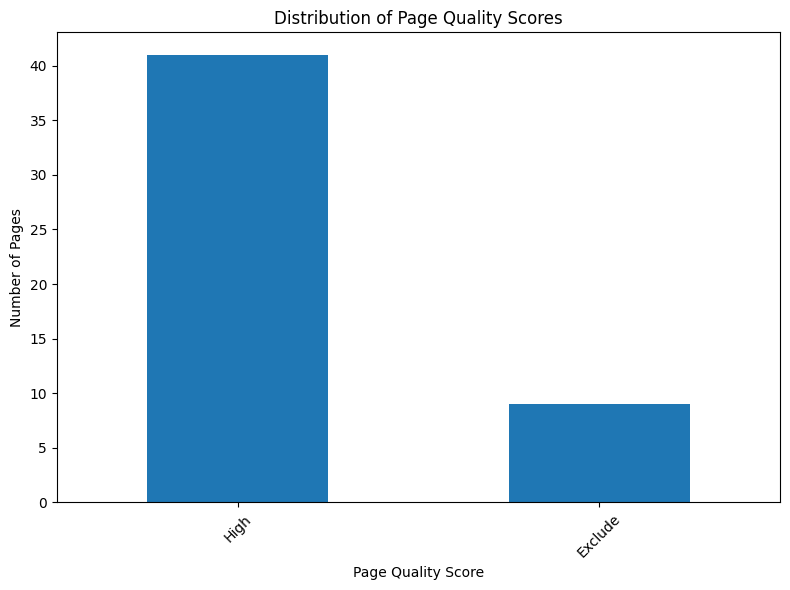

In [30]:
import matplotlib.pyplot as plt

# Get the value counts for 'Quality_Score'
quality_score_counts = cleaned_metadata_df['Quality_Score'].value_counts()

# Plotting the bar chart
plt.figure(figsize=(8, 6))
quality_score_counts.plot(kind='bar')
plt.title('Distribution of Page Quality Scores')
plt.xlabel('Page Quality Score')
plt.ylabel('Number of Pages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
cleaned_metadata_df.to_csv('cleaned_metadata.csv', index=False)
print("DataFrame 'cleaned_metadata_df' saved to 'cleaned_metadata.csv'")

DataFrame 'cleaned_metadata_df' saved to 'cleaned_metadata.csv'
